In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn


import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load DCIts
import sys
sys.path.append('../..')


# Load utils
from src.utils import *

# Set random seeds for reproducibility
seed = 42

torch.cuda.is_available()

# Check if CUDA is available
if torch.cuda.is_available():
    # Specify the device (index starts from 0, so cuda:0 is the first GPU)
    device = torch.device("cuda:0")
    print(f"Using {torch.cuda.get_device_name(device)}")
else:
    print("CUDA is not available. Using CPU instead.")
    device = torch.device("cpu")

Using NVIDIA GeForce RTX 5070


# Helper functions:

In [2]:
def coefficient_curve(kind, ts_length, **params):
    t = np.arange(ts_length)

    if kind == "sinusoidal":
        return params["a0"] + params["a1"] * np.sin(2 * np.pi * t / params["P"] + params["phi"])

    if kind == "monotonic_drift":
        return params["a_min"] + (params["a_max"] - params["a_min"]) * t / (ts_length - 1)

    if kind == "gaussian_pulse":
        return params["a0"] + params["a1"] * np.exp(-((t - params["t0"]) ** 2) / (2 * params["s"] ** 2))

    if kind == "zero_crossing_sine":
        return params["a1"] * np.sin(2 * np.pi * t / params["P"])

    raise ValueError(f"Unknown coefficient curve: {kind}")


def time_series_smooth_coefficient(
    mean,
    ts_length,
    coefficient_config,
    sigma_X1=0.05,
    sigma_X2=0.10,
    sigma_X3=0.15,
    sigma_X4=0.20,
    burn_in=1000,
    seed=None,
):
    if seed is not None:
        np.random.seed(seed)

    a_t = coefficient_curve(ts_length=ts_length, **coefficient_config)
    a_full = np.concatenate([np.full(burn_in, a_t[0]), a_t])
    total_length = ts_length + burn_in

    time_series = torch.zeros(4, total_length)
    time_series[:, 0:4] = torch.tensor(np.random.normal(0, 1, (4, 4)), dtype=torch.float32)

    for t in range(4, total_length):
        eta_X1 = np.random.normal(mean, sigma_X1)
        eta_X2 = np.random.normal(mean, sigma_X2)
        eta_X3 = np.random.normal(mean, sigma_X3)
        eta_X4 = np.random.normal(mean, sigma_X4)

        time_series[0, t] = 0.5 * time_series[0, t - 1] + eta_X1
        time_series[1, t] = 0.4 * time_series[1, t - 1] + a_full[t] * time_series[0, t - 2] + eta_X2
        time_series[2, t] = 0.5 * time_series[2, t - 1] + 0.6 * time_series[1, t - 1] + eta_X3
        time_series[3, t] = 0.3 * time_series[3, t - 1] + eta_X4

    return time_series[:, burn_in:], a_t


def test_window_times(ts_length, window_size, train_ratio=0.6, val_ratio=0.2):
    train_end = int(train_ratio * ts_length)
    val_end = train_end + int(val_ratio * ts_length)
    return np.arange(val_end + window_size, ts_length)


def sample_std(x, axis=0):
    x = np.asarray(x)
    n = x.shape[axis]
    return np.std(x, axis=axis, ddof=1 if n > 1 else 0)


def alpha_over_runs(results, order_idx=1):
    run_keys = [k for k in results if k.startswith("run_")]
    alpha_stack = np.stack([results[k]["alpha_seq"][order_idx] for k in run_keys], axis=0)
    alpha_mean_t = np.flip(alpha_stack.mean(axis=0), axis=3)
    alpha_std_t = np.flip(sample_std(alpha_stack, axis=0), axis=3)
    return alpha_mean_t, alpha_std_t


def plot_alpha_vs_true(alpha_mean_t, alpha_std_t, a_true, target, source, lag, names):
    y = alpha_mean_t[:, target, source, lag]
    s = alpha_std_t[:, target, source, lag]
    t = np.arange(len(y))

    plt.figure(figsize=(14, 4))
    plt.plot(t, y, label="mean alpha")
    plt.fill_between(t, y - s, y + s, alpha=0.25, color="red", label="+/- std")
    plt.plot(t, a_true, color="black", linewidth=2, linestyle="--", alpha=0.7, label="true a(t)")
    plt.axhline(0, color="gray", linewidth=1)
    plt.xlabel("test window")
    plt.ylabel("coefficient")
    plt.title(f"{names[source]} -> {names[target]}, lag {lag + 1}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    rmse = np.sqrt(np.mean((y - a_true) ** 2))

    if np.std(a_true) > 1e-12 and np.std(y) > 1e-12:
        corr = np.corrcoef(y, a_true)[0, 1]
        slope, intercept = np.polyfit(y, a_true, 1)
        calibrated = slope * y + intercept
        calibrated_rmse = np.sqrt(np.mean((calibrated - a_true) ** 2))
    else:
        corr = np.nan
        calibrated_rmse = np.nan

    print("corr(alpha, a(t)):", corr)
    print("RMSE alpha:", rmse)
    print("calibrated RMSE:", calibrated_rmse)

def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _to_float(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu().item())
    return float(x)


def _safe_corr(x, y):
    x = np.asarray(x, dtype=float).flatten()
    y = np.asarray(y, dtype=float).flatten()
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 2:
        return np.nan

    x = x[mask]
    y = y[mask]

    if np.std(x) <= 1e-12 or np.std(y) <= 1e-12:
        return np.nan

    return np.corrcoef(x, y)[0, 1]


def _mean_std(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    return values.mean(), sample_std(values)


def task3_metrics(
    results_case,
    stats_case,
    ground_truth_alpha,
    alpha_mean_t,
    alpha_std_t,
    a_t_test,
    case_name,
    names,
    threshold=0.04,
    c=1.95,
):
    run_keys = [k for k in results_case if k.startswith("run_")]

    mse_values = np.array([_to_float(results_case[k]["test_loss"]) for k in run_keys])
    mae_values = np.array([_to_float(results_case[k].get("test_mae", np.nan)) for k in run_keys])

    mean_mse, std_mse = _mean_std(mse_values)
    mean_mae, std_mae = _mean_std(mae_values)

    prediction_metrics = pd.DataFrame([
        {
            "case": case_name,
            "mean_MSE": mean_mse,
            "std_MSE": std_mse,
            "mean_MAE": mean_mae,
            "std_MAE": std_mae,
        }
    ])

    alpha_mean = np.flip(stats_case["alpha"][1]["mean"], axis=2)
    alpha_std = np.flip(stats_case["alpha"][1]["std"], axis=2)
    alpha_gt = _to_numpy(ground_truth_alpha).copy()

    true_mask = np.abs(alpha_gt) > 1e-12
    true_mask[1, 0, 1] = True  # X1 -> X2, lag 2 is active even when mean a(t) is near zero

    stable_mask = (np.abs(alpha_mean) > c * alpha_std) & (np.abs(alpha_mean) >= threshold)

    link_rows = []
    for target, source, lag in np.argwhere(stable_mask | true_mask):
        stable = bool(stable_mask[target, source, lag])
        true_link = bool(true_mask[target, source, lag])

        if stable and true_link:
            link_type = "true_positive"
        elif stable and not true_link:
            link_type = "false_positive"
        elif not stable and true_link:
            link_type = "missed_true_link"
        else:
            link_type = "true_negative"

        link_rows.append({
            "case": case_name,
            "source": names[source],
            "target": names[target],
            "lag": lag + 1,
            "mean_alpha": alpha_mean[target, source, lag],
            "std_alpha": alpha_std[target, source, lag],
            "ground_truth_alpha": alpha_gt[target, source, lag],
            "stable": stable,
            "true_link": true_link,
            "link_type": link_type,
        })

    lag_sign_rows = []
    for target, source, true_lag in np.argwhere(true_mask):
        estimated_lags = alpha_mean[target, source]
        best_lag = int(np.argmax(np.abs(estimated_lags)))
        gt_value = alpha_gt[target, source, true_lag]

        if abs(gt_value) <= 1e-12:
            correct_sign = np.nan
        else:
            correct_sign = np.sign(estimated_lags[true_lag]) == np.sign(gt_value)

        lag_sign_rows.append({
            "case": case_name,
            "source": names[source],
            "target": names[target],
            "true_lag": true_lag + 1,
            "estimated_best_lag": best_lag + 1,
            "correct_lag": best_lag == true_lag,
            "ground_truth_alpha": gt_value,
            "estimated_alpha_true_lag": estimated_lags[true_lag],
            "estimated_alpha_best_lag": estimated_lags[best_lag],
            "correct_sign": correct_sign,
        })

    link_table = pd.DataFrame(link_rows)
    lag_sign_table = pd.DataFrame(lag_sign_rows)

    false_positive_table = link_table[link_table["link_type"] == "false_positive"].copy()
    if len(false_positive_table) > 0:
        false_positive_table["abs_mean_alpha"] = false_positive_table["mean_alpha"].abs()
        false_positive_table = false_positive_table.sort_values("abs_mean_alpha", ascending=False)

    fp_values = alpha_mean[stable_mask & ~true_mask]
    mfp_t = np.abs(alpha_mean_t[:, ~true_mask]).sum(axis=1)

    y = alpha_mean_t[:, 1, 0, 1]
    s = alpha_std_t[:, 1, 0, 1]
    n = min(len(y), len(a_t_test))
    y = y[:n]
    a_true = np.asarray(a_t_test)[:n]

    tracking_rmse = np.sqrt(np.mean((y - a_true) ** 2))
    tracking_corr = _safe_corr(y, a_true)

    if np.std(a_true) > 1e-12 and np.std(y) > 1e-12:
        slope, intercept = np.polyfit(y, a_true, 1)
        calibrated = slope * y + intercept
        calibrated_rmse = np.sqrt(np.mean((calibrated - a_true) ** 2))
    else:
        calibrated_rmse = np.nan

    sign_values = pd.Series(lag_sign_table["correct_sign"]).dropna()

    summary_metrics = pd.DataFrame([
        {
            "case": case_name,
            "alpha_correlation_global_mean": _safe_corr(alpha_mean, alpha_gt),
            "main_link_tracking_corr": tracking_corr,
            "main_link_RMSE": tracking_rmse,
            "main_link_calibrated_RMSE": calibrated_rmse,
            "lag_accuracy": lag_sign_table["correct_lag"].mean(),
            "sign_accuracy": sign_values.mean() if len(sign_values) > 0 else np.nan,
            "true_positives": int(np.sum(stable_mask & true_mask)),
            "false_positives": int(np.sum(stable_mask & ~true_mask)),
            "missed_true_links": int(np.sum(~stable_mask & true_mask)),
            "max_false_positive_strength": 0.0 if len(fp_values) == 0 else np.max(np.abs(fp_values)),
            "mean_false_positive_strength": 0.0 if len(fp_values) == 0 else np.mean(np.abs(fp_values)),
            "mean_M_FP_t": mfp_t.mean(),
            "max_M_FP_t": mfp_t.max(),
            "mean_alpha_std_all": alpha_std.mean(),
            "mean_alpha_std_true_links": alpha_std[true_mask].mean(),
            "max_alpha_std_true_links": alpha_std[true_mask].max(),
            "mean_main_link_std_t": s[:n].mean(),
            "max_main_link_std_t": s[:n].max(),
        }
    ])

    return prediction_metrics, summary_metrics, lag_sign_table, link_table, false_positive_table


# Parameters:

$$
\begin{split}
X_{1,t} &= 0.5 X_{1,t-1} + \eta_{1,t}, \\
X_{2,t} &= 0.4 X_{2,t-1} + a(t) X_{1,t-2} + \eta_{2,t}, \\
X_{3,t} &= 0.5 X_{3,t-1} + 0.6 X_{2,t-1} + \eta_{3,t}, \\
X_{4,t} &= 0.3 X_{4,t-1} + \eta_{4,t}.
\end{split}
$$

### Main coefficient curve

$$
a(t) = a_0 + a_1 \sin \left( \frac{2 \pi t}{P} + \phi \right)
$$

$$
a_0 = 0.5, \quad a_1 \in \{0.1, 0.25, 0.4\}, \quad P \in \{100, 500, 2000\}, \quad \phi \in \{0, \pi/4, \pi/2\}
$$

The actual time-varying link is:

$$
X_{1,t-2} \rightarrow X_{2,t} \quad \text{with strength } a(t).
$$

### Additional coefficient curves

**Monotonic drift:**
$$
a(t) = a_{\min} + (a_{\max} - a_{\min}) \frac{t}{T}
$$

**Localized Gaussian change:**
$$
a(t) = a_0 + a_1 \exp \left[ -\frac{(t - t_0)^2}{2s^2} \right]
$$

**Zero-crossing sine:**
$$
a(t) = a_1 \sin \left( \frac{2\pi t}{P} \right)
$$



In [3]:
mean = 0
sigma_X1 = 1
sigma_X2 = 0.05
sigma_X3 = 0.05
sigma_X4 = 0.1

ts_length = 20000
burn_in = 1000
seed = 42

no_of_timeseries_gp = 4
window_length_gp = 5
names = ["X1", "X2", "X3", "X4"]

# DCIts setup
n_runs = 5
temperature = 1.0
order = [1, 1]

# PDF parameter grid for the main sinusoidal coefficient
parameter_grid = {
    "a1_values": [0.10, 0.25, 0.40],
    "P_values": [100, 500, 2000],
    "phi_values": [0, np.pi / 4, np.pi / 2],
}

# One default case for notebook development
a0 = 0.5
a1 = 0.25
P = 500
phi = 0





coefficient_cases = {
    "sinusoidal": {
        "kind": "sinusoidal",
        "a0": a0,
        "a1": a1,
        "P": P,
        "phi": phi,
    },
    "monotonic_drift": {
        "kind": "monotonic_drift",
        "a_min": 0.10,
        "a_max": 0.90,
    },
    # Gaussian pulse:
    # a(t) = a0 + a1 * exp(-((t - t0)^2) / (2 * s^2))
    #
    # a0 controls the baseline / lowest value.
    # Far away from the pulse, a(t) is approximately a0.
    #
    # a1 controls peak height.
    # Peak is roughly a0 + a1.
    # Example: a0 = 0.35 and a1 = 0.50 gives peak around 0.85.
    #
    # t0 controls where the peak happens.
    # Example with train/val/test = 60%/20%/20%:
    # t0 = 0.50 * T -> peak is in train
    # t0 = 0.60 * T -> peak is near train/val border
    # t0 = 0.80 * T -> peak is near val/test border
    #
    # s controls width / spread.
    # Larger s means wider pulse.
    # s = 0.08 * T -> narrow pulse
    # s = 0.15 * T -> medium pulse
    # s = 0.25 * T -> wide pulse, visible in train/val/test
    "gaussian_pulse": {
    "kind": "gaussian_pulse",
    "a0": 0.1,
    "a1": 0.75,
    "t0": int(0.60 * ts_length),
    "s": int(0.30 * ts_length),
    },
    "zero_crossing_sine": {
        "kind": "zero_crossing_sine",
        "a1": 0.60,
        "P": 500,
    },
}

case_name_sin = "sinusoidal"
coefficient_config_sin = coefficient_cases[case_name_sin]
a_t_sin = coefficient_curve(ts_length=ts_length, **coefficient_config_sin)

case_name_drift = "monotonic_drift"
coefficient_config_drift = coefficient_cases[case_name_drift]
a_t_drift = coefficient_curve(ts_length=ts_length, **coefficient_config_drift)

case_name_pulse = "gaussian_pulse"
coefficient_config_pulse = coefficient_cases[case_name_pulse]
a_t_pulse = coefficient_curve(ts_length=ts_length, **coefficient_config_pulse)

case_name_zero = "zero_crossing_sine"
coefficient_config_zero = coefficient_cases[case_name_zero]
a_t_zero = coefficient_curve(ts_length=ts_length, **coefficient_config_zero)



t_test = test_window_times(ts_length, window_length_gp)

a_t_test_sin = a_t_sin[t_test]
a_t_test_drift = a_t_drift[t_test]
a_t_test_pulse = a_t_pulse[t_test]
a_t_test_zero = a_t_zero[t_test]


def make_ground_truth_alpha(a_t):
    gt = torch.zeros(no_of_timeseries_gp, no_of_timeseries_gp, window_length_gp)

    gt[0, 0, 0] = 0.5  # X1_t <- X1_{t-1}
    gt[1, 1, 0] = 0.4  # X2_t <- X2_{t-1}
    gt[2, 2, 0] = 0.5  # X3_t <- X3_{t-1}
    gt[3, 3, 0] = 0.3  # X4_t <- X4_{t-1}

    gt[1, 0, 1] = float(np.mean(a_t))  # X2_t <- X1_{t-2}
    gt[2, 1, 0] = 0.6                 # X3_t <- X2_{t-1}

    return gt

ground_truth_alpha_sin = make_ground_truth_alpha(a_t_test_sin)
ground_truth_alpha_drift = make_ground_truth_alpha(a_t_test_drift)
ground_truth_alpha_pulse = make_ground_truth_alpha(a_t_test_pulse)
ground_truth_alpha_zero = make_ground_truth_alpha(a_t_test_zero)

alpha_mask_sin = (ground_truth_alpha_sin != 0).float()
alpha_mask_drift = (ground_truth_alpha_drift != 0).float()
alpha_mask_pulse = (ground_truth_alpha_pulse != 0).float()
alpha_mask_zero = (ground_truth_alpha_zero != 0).float()

ground_truth_bias = torch.zeros(no_of_timeseries_gp)




In [8]:

train_config = {
    "verbose": False,
    "device": device,
    "learning_rate": 1e-3,
    "scheduler_patience": 5,
    "early_stopping_modifier": 2,
    "criterion": nn.MSELoss(),
    #"criterion": nn.HuberLoss(delta=0.1),
    # "min_epochs": 50,
    # "epochs": 300,
}

# Generate data and plot


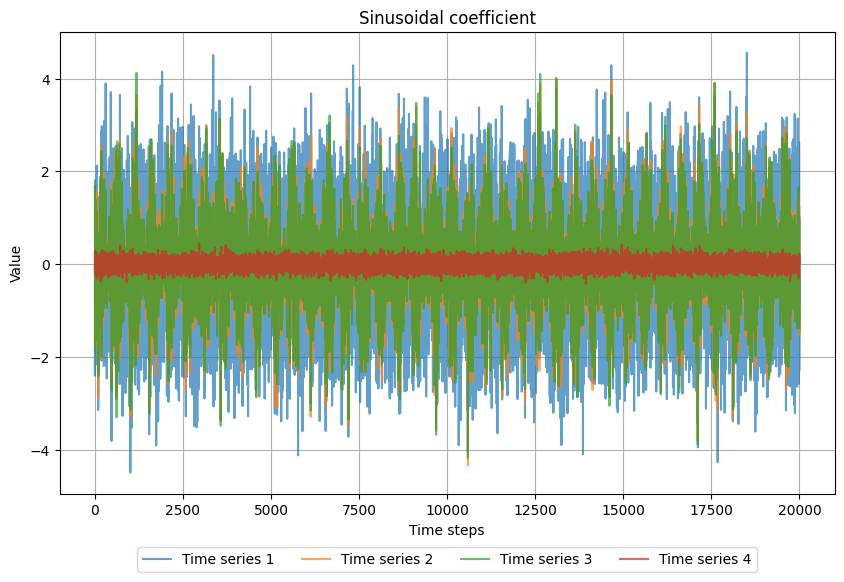

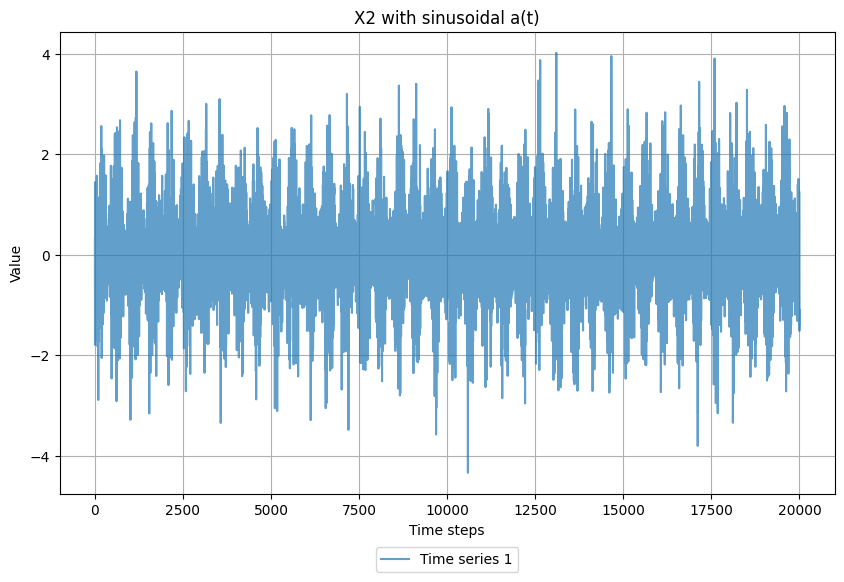

In [9]:
time_series_sin, a_t_sin = time_series_smooth_coefficient(mean=mean, ts_length=ts_length, coefficient_config=coefficient_config_sin, sigma_X1=sigma_X1, sigma_X2=sigma_X2, sigma_X3=sigma_X3, sigma_X4=sigma_X4, burn_in=burn_in, seed=seed)

time_series_drift, a_t_drift = time_series_smooth_coefficient(mean=mean, ts_length=ts_length, coefficient_config=coefficient_config_drift, sigma_X1=sigma_X1, sigma_X2=sigma_X2, sigma_X3=sigma_X3, sigma_X4=sigma_X4, burn_in=burn_in, seed=seed)

time_series_pulse, a_t_pulse = time_series_smooth_coefficient(mean=mean, ts_length=ts_length, coefficient_config=coefficient_config_pulse, sigma_X1=sigma_X1, sigma_X2=sigma_X2, sigma_X3=sigma_X3, sigma_X4=sigma_X4, burn_in=burn_in, seed=seed)

time_series_zero, a_t_zero = time_series_smooth_coefficient(mean=mean, ts_length=ts_length, coefficient_config=coefficient_config_zero, sigma_X1=sigma_X1, sigma_X2=sigma_X2, sigma_X3=sigma_X3, sigma_X4=sigma_X4, burn_in=burn_in, seed=seed)

plot_ts(time_series_sin, dataset_name="Sinusoidal coefficient")
plot_ts(time_series_sin[1:2, :], dataset_name="X2 with sinusoidal a(t)")

#plot_ts(time_series_drift, dataset_name="Monotonic drift coefficient")
#plot_ts(time_series_pulse, dataset_name="Gaussian pulse coefficient")
#plot_ts(time_series_zero, dataset_name="Zero-crossing sine coefficient")

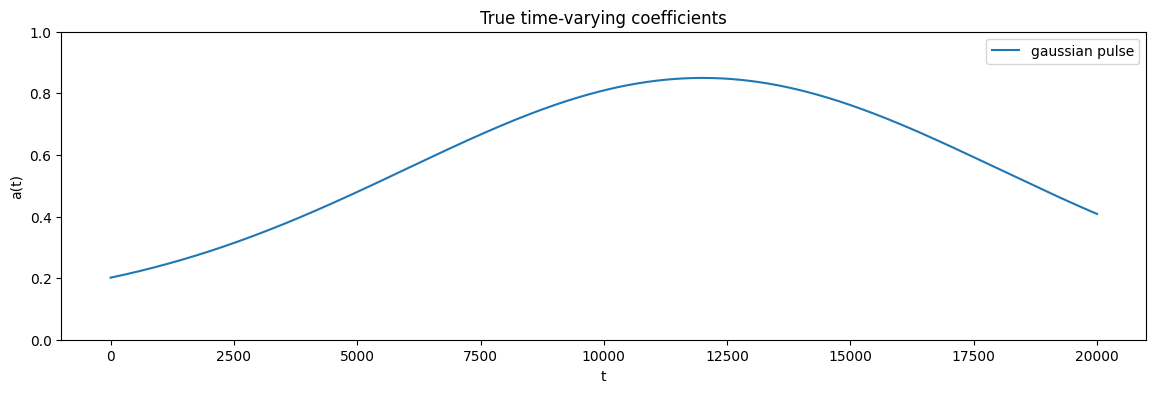

In [10]:
t = np.arange(ts_length)
plt.figure(figsize=(14, 4))
#plt.plot(t, a_t_sin, label="sinusoidal")
#plt.plot(t, a_t_drift, label="monotonic drift")
plt.plot(t, a_t_pulse, label="gaussian pulse")
#plt.plot(t, a_t_zero, label="zero-crossing sine")
plt.xlabel("t")
plt.ylabel("a(t)")
plt.title("True time-varying coefficients")
plt.ylim(0,1)
plt.legend()
plt.show()

# Sinusoidal


In [11]:
results = collect_multiple_runs(
    n_runs=n_runs,
    time_series=time_series_sin,
    window_size=window_length_gp,
    temperature=temperature,
    order=order,
    config=train_config,
    verbose=True,
)

stats = calculate_multiple_run_statistics(results)
global_alpha = stats["alpha"][1]["mean"]



Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 2.576179e-01
Starting Run 2/5
Run 2 completed. Test Loss: 2.576367e-01
Starting Run 3/5
Run 3 completed. Test Loss: 2.576224e-01
Starting Run 4/5
Run 4 completed. Test Loss: 2.574580e-01
Starting Run 5/5
Run 5 completed. Test Loss: 2.578345e-01
Time taken for 5 run(s): 58.70 seconds


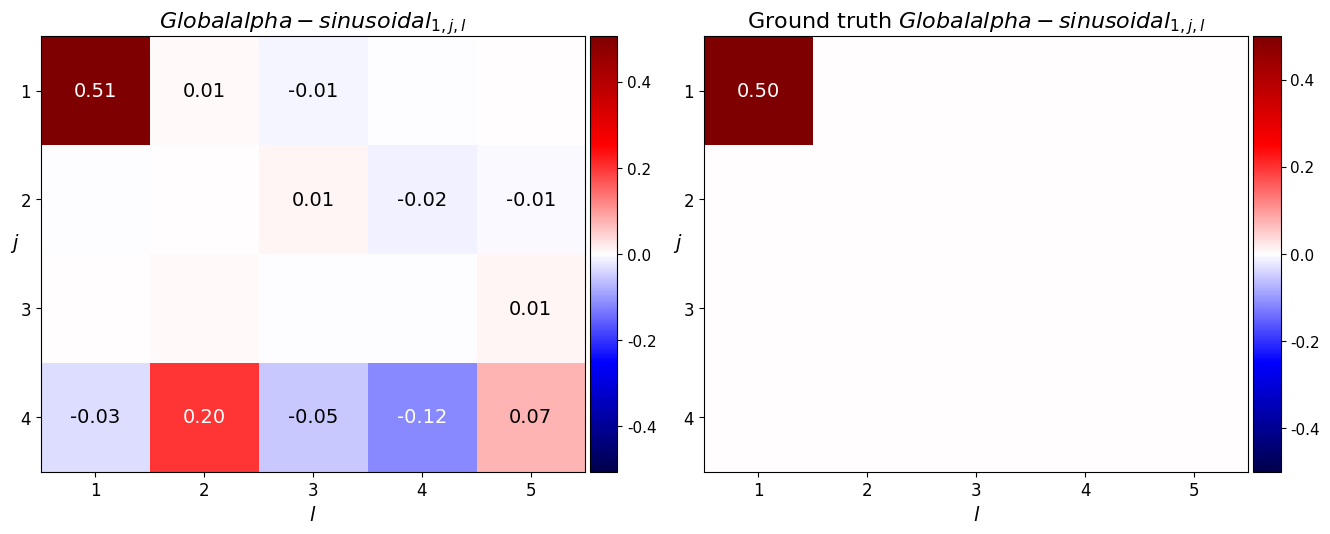

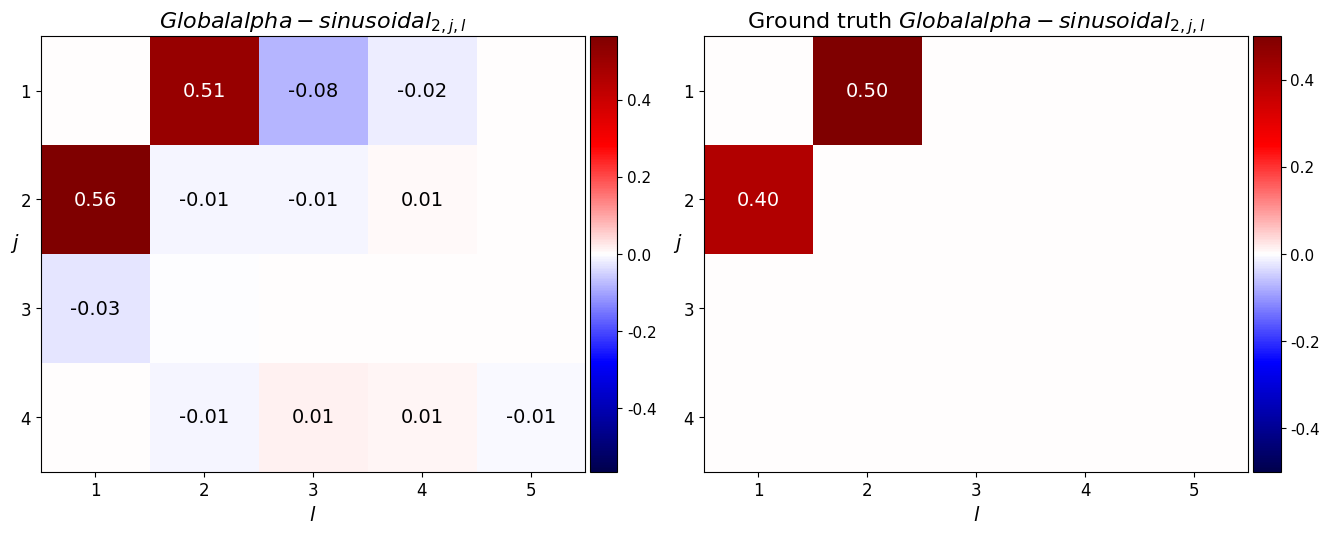

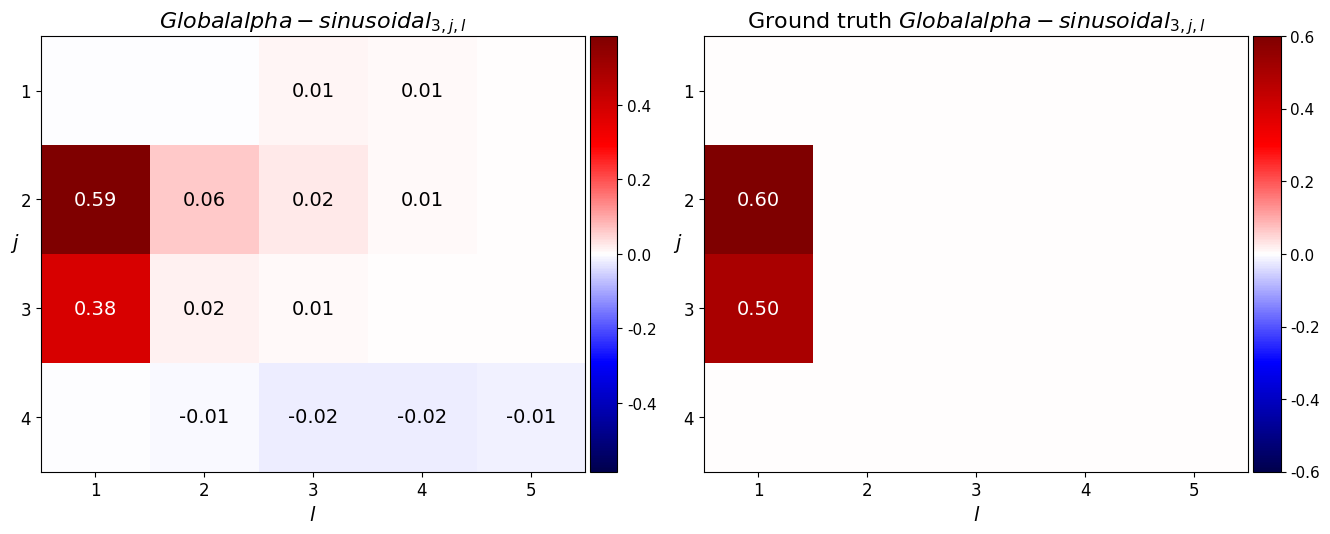

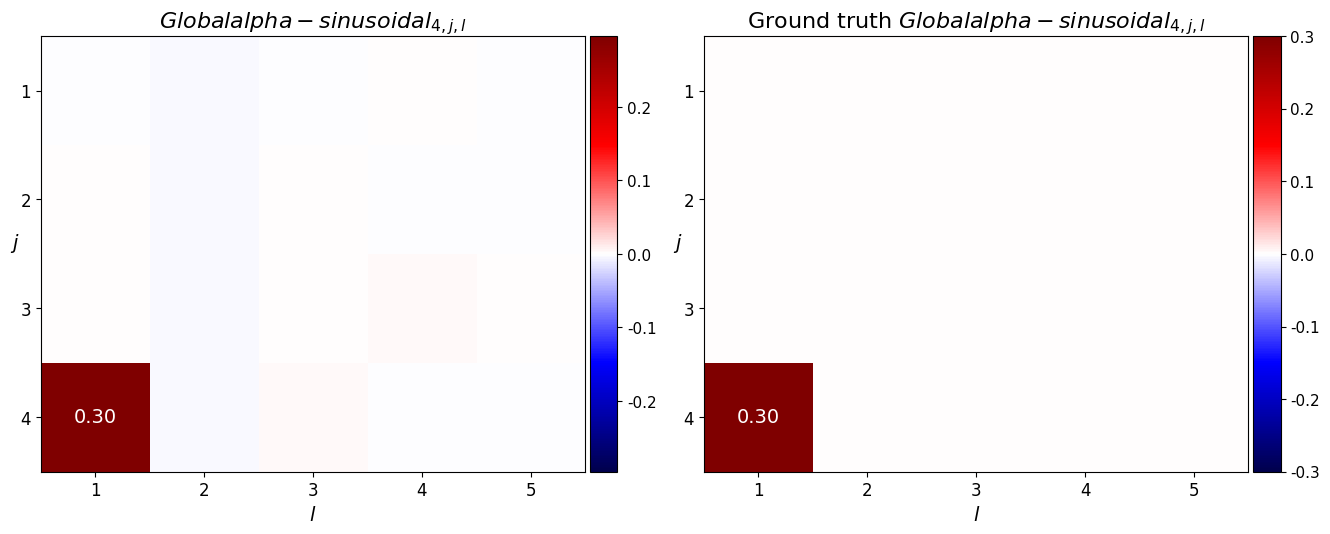

In [12]:
plot_alphas(global_alpha, ground_truth_alpha_sin, title="Global alpha - sinusoidal", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats["f"][1]["mean"], alpha_mask_sin, title=r"f - sinusoidal", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats["c"][1]["mean"], alpha_mask_sin, title=r"C - sinusoidal", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

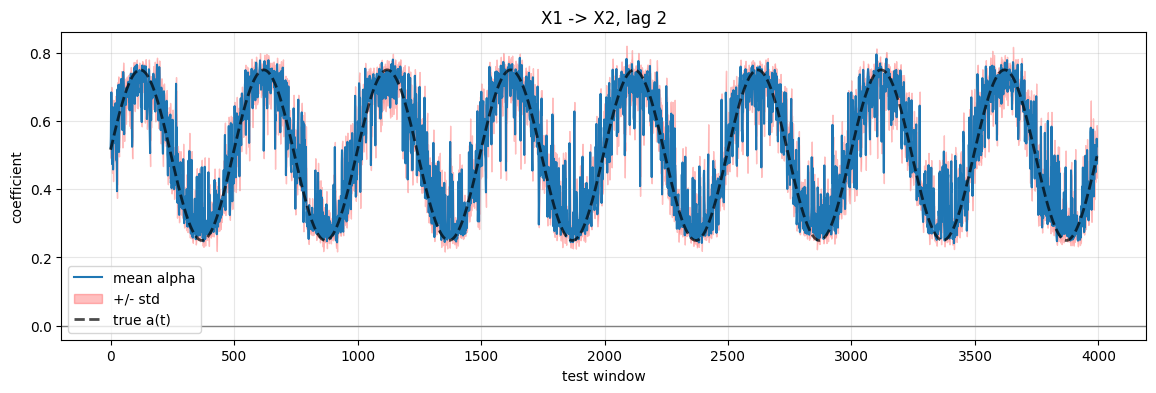

corr(alpha, a(t)): 0.9232879278402619
RMSE alpha: 0.06902705568726743
calibrated RMSE: 0.06794384339909532


In [13]:
alpha_mean_t_sin, alpha_std_t_sin = alpha_over_runs(results)

plot_alpha_vs_true(
    alpha_mean_t_sin,
    alpha_std_t_sin,
    a_t_test_sin,
    target=1,
    source=0,
    lag=1,
    names=names,
)

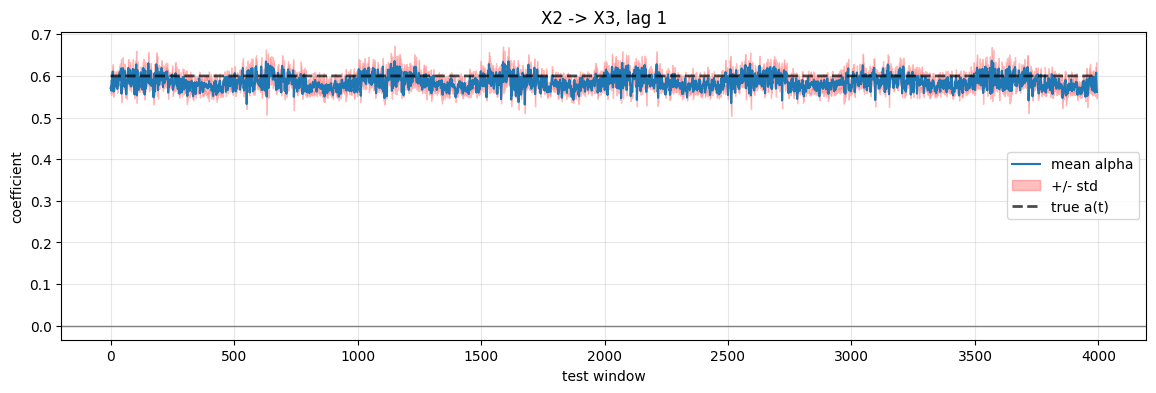

corr(alpha, a(t)): nan
RMSE alpha: 0.02190362307867176
calibrated RMSE: nan


In [14]:
plot_alpha_vs_true(alpha_mean_t_sin, alpha_std_t_sin, np.full_like(a_t_test_sin, 0.6), target=2, source=1, lag=0, names=names)

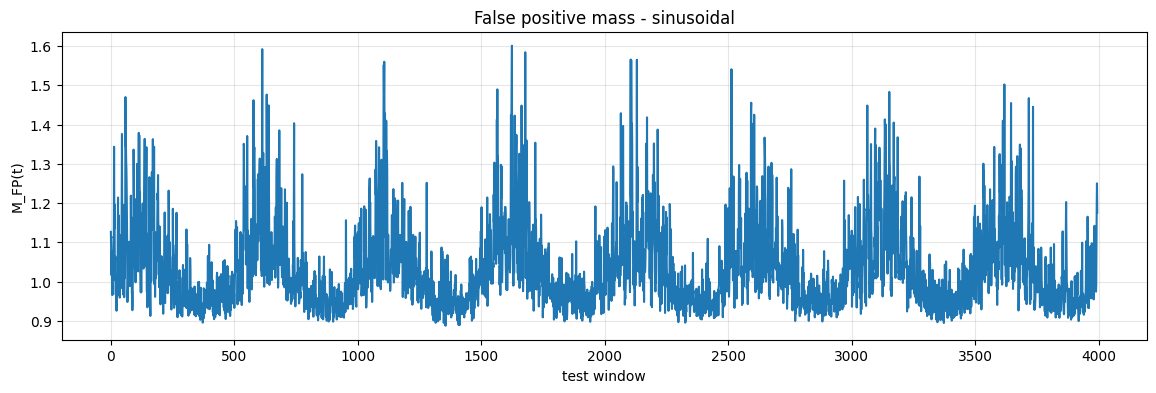

mean M_FP: 1.0322784
max M_FP: 1.6009114


In [15]:
true_mask_sin = ground_truth_alpha_sin.numpy() != 0
true_mask_sin[1, 0, 1] = True

mfp_sin = np.abs(alpha_mean_t_sin[:, ~true_mask_sin]).sum(axis=1)

plt.figure(figsize=(14, 4))
plt.plot(mfp_sin)
plt.xlabel("test window")
plt.ylabel("M_FP(t)")
plt.title("False positive mass - sinusoidal")
plt.grid(alpha=0.3)
plt.show()

print("mean M_FP:", mfp_sin.mean())
print("max M_FP:", mfp_sin.max())


In [16]:
sin_prediction_metrics, sin_summary_metrics, sin_lag_sign_table, sin_link_table, sin_false_positive_table = task3_metrics(
    results,
    stats,
    ground_truth_alpha_sin,
    alpha_mean_t_sin,
    alpha_std_t_sin,
    a_t_test_sin,
    "sinusoidal",
    names,
)

display(sin_prediction_metrics)
display(sin_summary_metrics)
display(sin_lag_sign_table)
display(sin_link_table)
display(sin_false_positive_table)


,case,mean_MSE,std_MSE,mean_MAE,std_MAE
0,sinusoidal,0.257634,0.000134,0.248072,0.000447


,case,alpha_correlation_global_mean,main_link_tracking_corr,main_link_RMSE,main_link_calibrated_RMSE,lag_accuracy,sign_accuracy,true_positives,false_positives,missed_true_links,max_false_positive_strength,mean_false_positive_strength,mean_M_FP_t,max_M_FP_t,mean_alpha_std_all,mean_alpha_std_true_links,max_alpha_std_true_links,mean_main_link_std_t,max_main_link_std_t
0,sinusoidal,0.956353,0.923288,0.069027,0.067944,1.0,1.0,6,6,0,0.198058,0.096915,1.032278,1.600911,0.007286,0.013423,0.029866,0.025284,0.116123


,case,source,target,true_lag,estimated_best_lag,correct_lag,ground_truth_alpha,estimated_alpha_true_lag,estimated_alpha_best_lag,correct_sign
0,sinusoidal,X1,X1,1,1,True,0.5,0.505996,0.505996,True
1,sinusoidal,X1,X2,2,2,True,0.5,0.511271,0.511271,True
2,sinusoidal,X2,X2,1,1,True,0.4,0.564667,0.564667,True
3,sinusoidal,X2,X3,1,1,True,0.6,0.585075,0.585075,True
4,sinusoidal,X3,X3,1,1,True,0.5,0.381960,0.381960,True
5,sinusoidal,X4,X4,1,1,True,0.3,0.296396,0.296396,True


,case,source,target,lag,mean_alpha,std_alpha,ground_truth_alpha,stable,true_link,link_type
0,sinusoidal,X1,X1,1,0.505996,0.001986,0.5,True,True,true_positive
1,sinusoidal,X4,X1,2,0.198058,0.021271,0.0,True,False,false_positive
2,sinusoidal,X4,X1,3,-0.053546,0.019557,0.0,True,False,false_positive
3,sinusoidal,X4,X1,4,-0.115773,0.014436,0.0,True,False,false_positive
4,sinusoidal,X4,X1,5,0.074337,0.034718,0.0,True,False,false_positive
5,sinusoidal,X1,X2,2,0.511271,0.007916,0.5,True,True,true_positive
6,sinusoidal,X1,X2,3,-0.079983,0.005883,0.0,True,False,false_positive
7,sinusoidal,X2,X2,1,0.564667,0.025469,0.4,True,True,true_positive
8,sinusoidal,X2,X3,1,0.585075,0.011991,0.6,True,True,true_positive
9,sinusoidal,X2,X3,2,0.059792,0.013447,0.0,True,False,false_positive


,case,source,target,lag,mean_alpha,std_alpha,ground_truth_alpha,stable,true_link,link_type,abs_mean_alpha
1,sinusoidal,X4,X1,2,0.198058,0.021271,0.0,True,False,false_positive,0.198058
3,sinusoidal,X4,X1,4,-0.115773,0.014436,0.0,True,False,false_positive,0.115773
6,sinusoidal,X1,X2,3,-0.079983,0.005883,0.0,True,False,false_positive,0.079983
4,sinusoidal,X4,X1,5,0.074337,0.034718,0.0,True,False,false_positive,0.074337
9,sinusoidal,X2,X3,2,0.059792,0.013447,0.0,True,False,false_positive,0.059792
2,sinusoidal,X4,X1,3,-0.053546,0.019557,0.0,True,False,false_positive,0.053546


In [17]:
L = window_length_gp

train_end_global = int(0.8 * ts_length)
test_start_global = train_end_global + L

data = pd.DataFrame(time_series_sin.T, columns=names)

global_fit = VAR(data.iloc[:train_end_global]).fit(L)

global_pred = []

for t in range(test_start_global, len(data)):
    yhat = global_fit.forecast(data.iloc[t-L:t].values, steps=1)[0]
    global_pred.append(yhat)

global_pred = np.array(global_pred)
global_true = data.iloc[test_start_global:].values

print("Global VAR MSE:", mean_squared_error(global_true, global_pred))
print("Global VAR MAE:", mean_absolute_error(global_true, global_pred))

global_coef = global_fit.coefs[1, 1, 0]  # lag 2, X2 target, X1 source
print("Global VAR X1 -> X2 lag 2:", global_coef)


Global VAR MSE: 0.2638528889477616
Global VAR MAE: 0.26470051495306335
Global VAR X1 -> X2 lag 2: 0.49901761350823043


In [18]:
global_coef = global_fit.coefs[1, 1, 0]
print("Global VAR X1 -> X2 lag 2:", global_coef)
print("Mean true a(t):", np.mean(a_t_test_sin))


Global VAR X1 -> X2 lag 2: 0.49901761350823043
Mean true a(t): 0.4999921382580616


In [19]:
L = window_length_gp
#W = 20
W = 100

train_end = int(0.6 * ts_length)
val_end = train_end + int(0.2 * ts_length)
test_start = val_end + L

data = pd.DataFrame(time_series_sin.T, columns=names)

sliding_pred = []
sliding_coef = []

for t in range(test_start, len(data)):
    local_data = data.iloc[t-W:t]

    local_fit = VAR(local_data).fit(L)
    yhat = local_fit.forecast(data.iloc[t-L:t].values, steps=1)[0]

    sliding_pred.append(yhat)
    sliding_coef.append(local_fit.coefs[1, 1, 0])  # X1 -> X2, lag 2

sliding_pred = np.array(sliding_pred)
sliding_coef = np.array(sliding_coef)
true = data.iloc[test_start:].values

print("Sliding VAR MSE:", mean_squared_error(true, sliding_pred))
print("Sliding VAR MAE:", mean_absolute_error(true, sliding_pred))


Sliding VAR MSE: 0.34657665446441843
Sliding VAR MAE: 0.2905892747529428


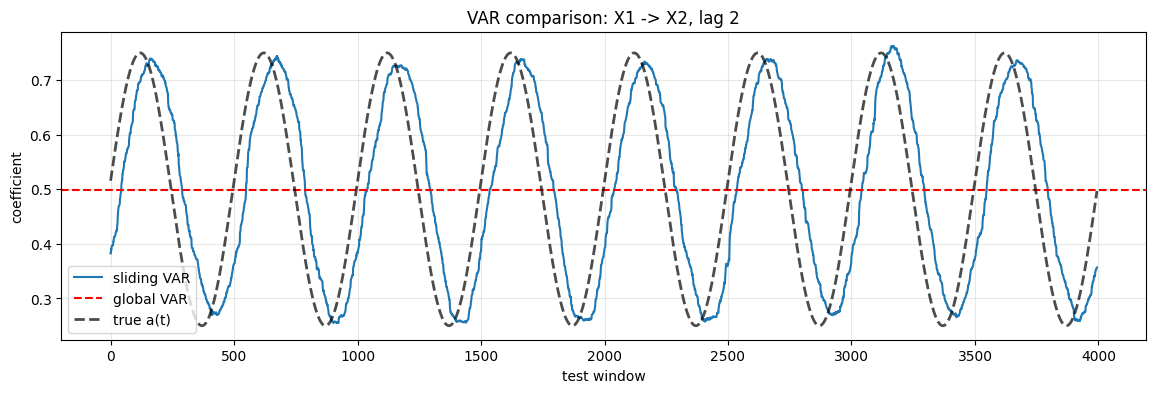

In [20]:
plt.figure(figsize=(14, 4))

plt.plot(sliding_coef, label="sliding VAR")
plt.axhline(global_coef, color="red", linestyle="--", label="global VAR")
plt.plot(a_t_test_sin, color="black", linestyle="--", alpha=0.7, linewidth=2, label="true a(t)")

plt.xlabel("test window")
plt.ylabel("coefficient")
plt.title("VAR comparison: X1 -> X2, lag 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Pipeline heatmap ploting test:

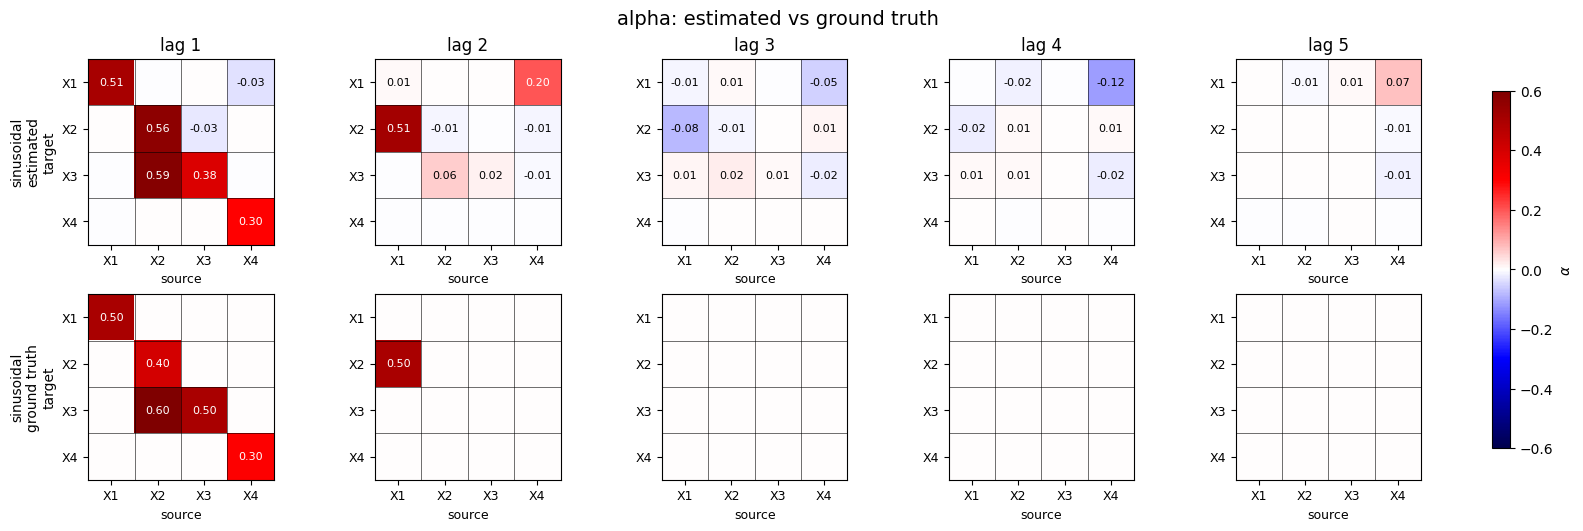

In [22]:
def plot_smooth_metric_lag_comparison(
    smooth_cases,
    case_order,
    metric="alpha",
    alpha_key=1,
    cmap="seismic",
    save_path=None,
):
    estimated_by_case = []
    truth_by_case = []
    case_titles = []

    for case_name in case_order:
        case = smooth_cases[case_name]

        if metric == "alpha":
            estimated = case["stats"]["alpha"][alpha_key]["mean"]
            truth = case["ground_truth_alpha"].detach().cpu().numpy()
            colorbar_label = r"$\alpha$"
        elif metric == "focuser":
            estimated = case["stats"]["f"][alpha_key]["mean"]
            truth = case["alpha_mask"].detach().cpu().numpy()
            colorbar_label = "Focuser"
        elif metric == "coefficient":
            estimated = case["stats"]["c"][alpha_key]["mean"]
            truth = case["alpha_mask"].detach().cpu().numpy()
            colorbar_label = "Coefficient"
        else:
            raise ValueError(f"Unknown metric: {metric}")

        estimated_by_case.append(np.flip(estimated, axis=2))
        truth_by_case.append(truth)
        case_titles.append(case["title"])

    n_cases = len(case_order)
    n_lags = estimated_by_case[0].shape[2]
    n_rows = 2 * n_cases
    n_series = estimated_by_case[0].shape[0]

    vmax = max(
        max(np.max(np.abs(est)), np.max(np.abs(truth)))
        for est, truth in zip(estimated_by_case, truth_by_case)
    )
    vmax = max(vmax, 1e-12)

    fig, axes = plt.subplots(
        n_rows,
        n_lags,
        figsize=(3.2 * n_lags, 2.6 * n_rows),
        constrained_layout=True,
    )

    if n_rows == 1:
        axes = np.array([axes])

    for case_idx, (case_title, estimated, truth) in enumerate(
        zip(case_titles, estimated_by_case, truth_by_case)
    ):
        for row_offset, row_label in [
            (0, "estimated"),
            (1, "ground truth"),
        ]:
            row_idx = 2 * case_idx + row_offset
            data = estimated if row_offset == 0 else truth

            for lag_idx in range(n_lags):
                ax = axes[row_idx, lag_idx]
                matrix = data[:, :, lag_idx]

                im = ax.imshow(
                    matrix,
                    cmap=cmap,
                    vmin=-vmax,
                    vmax=vmax,
                    aspect="equal",
                )

                data_rounded = np.round(matrix, 2)

                for target_idx in range(n_series):
                    for source_idx in range(n_series):
                        value = data_rounded[target_idx, source_idx]
                        if value != 0:
                            text_color = "black" if abs(value) < 0.2 * vmax else "white"
                            ax.text(
                                source_idx,
                                target_idx,
                                f"{value:.2f}",
                                ha="center",
                                va="center",
                                color=text_color,
                                fontsize=8,
                            )

                if row_idx == 0:
                    ax.set_title(f"lag {lag_idx + 1}", fontsize=12)

                if lag_idx == 0:
                    ax.set_ylabel(f"{case_title}\n{row_label}\ntarget", fontsize=10)

                ax.set_xticks(range(n_series))
                ax.set_yticks(range(n_series))
                ax.set_xticklabels(names, fontsize=9)
                ax.set_yticklabels(names, fontsize=9)
                ax.set_xlabel("source", fontsize=9)

                ax.set_xticks(np.arange(-0.5, n_series, 1), minor=True)
                ax.set_yticks(np.arange(-0.5, n_series, 1), minor=True)
                ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
                ax.tick_params(which="minor", bottom=False, left=False)

    fig.colorbar(im, ax=axes, shrink=0.85, label=colorbar_label)
    fig.suptitle(f"{metric}: estimated vs ground truth", fontsize=14)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
        
        
smooth_cases_plot_test = {
    "sinusoidal": {
        "title": "sinusoidal",
        "stats": stats,
        "ground_truth_alpha": ground_truth_alpha_sin,
        "alpha_mask": alpha_mask_sin,
    }
}

plot_smooth_metric_lag_comparison(
    smooth_cases_plot_test,
    case_order=["sinusoidal"],
    metric="alpha",
)

# Monotonic_drift


In [56]:
results_drift = collect_multiple_runs(
    n_runs=n_runs,
    time_series=time_series_drift,
    window_size=window_length_gp,
    temperature=temperature,
    order=order,
    config=train_config,
    verbose=True,
)

stats_drift = calculate_multiple_run_statistics(results_drift)
global_alpha_drift = stats_drift["alpha"][1]["mean"]



Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 2.843044e-01
Starting Run 2/5
Run 2 completed. Test Loss: 2.819287e-01
Starting Run 3/5
Run 3 completed. Test Loss: 2.819522e-01
Starting Run 4/5
Run 4 completed. Test Loss: 2.861133e-01
Starting Run 5/5
Run 5 completed. Test Loss: 2.802481e-01
Time taken for 5 run(s): 26.33 seconds


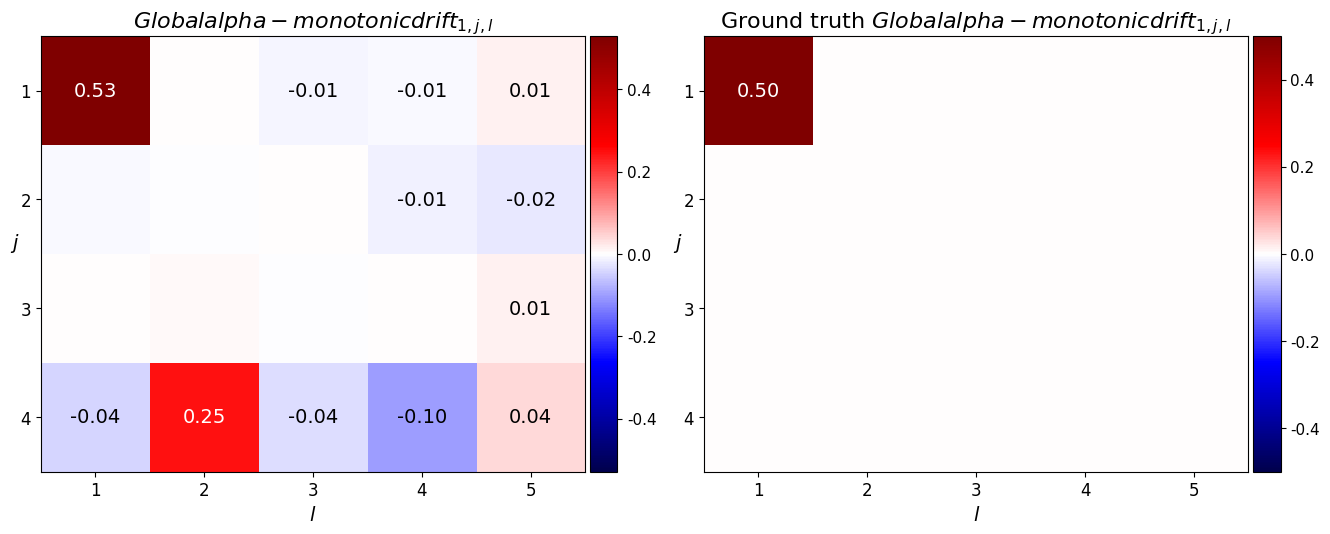

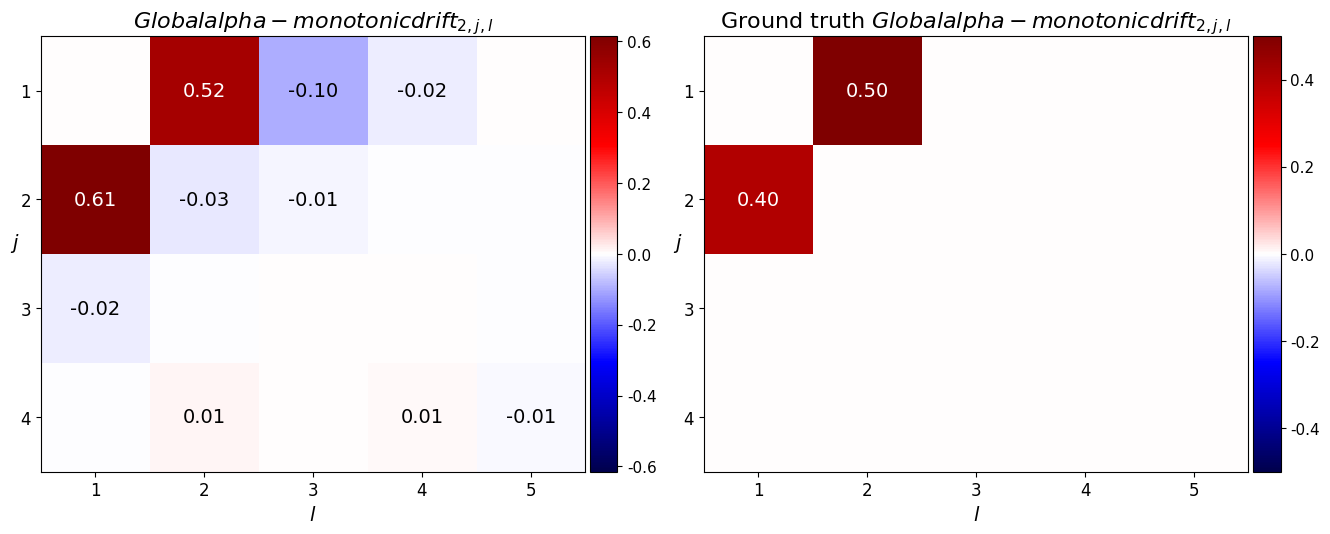

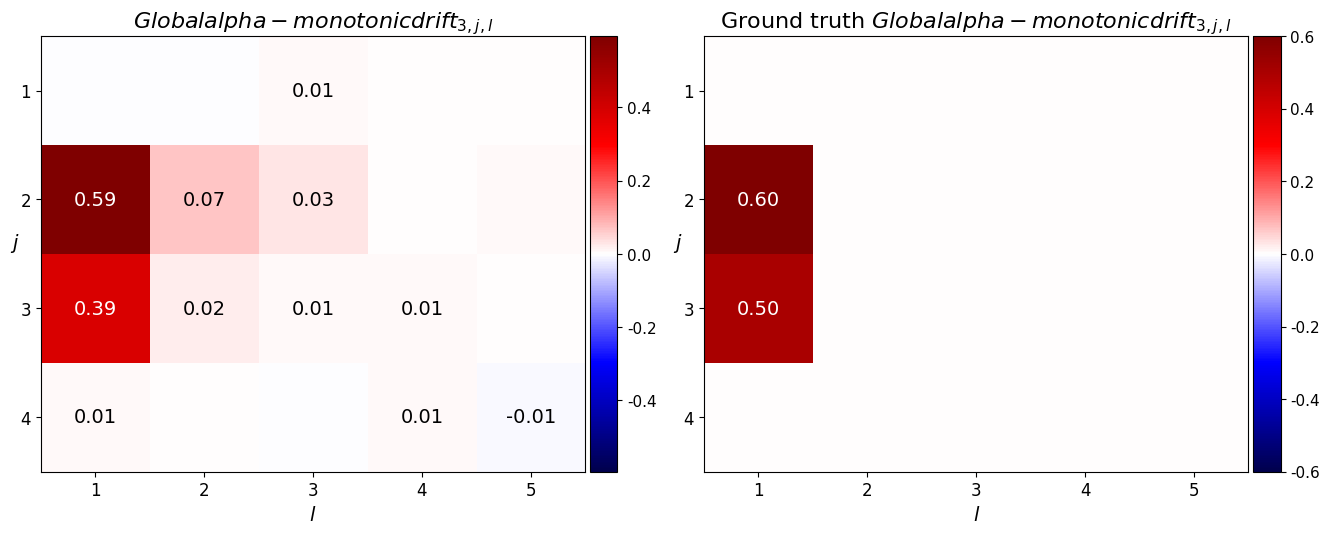

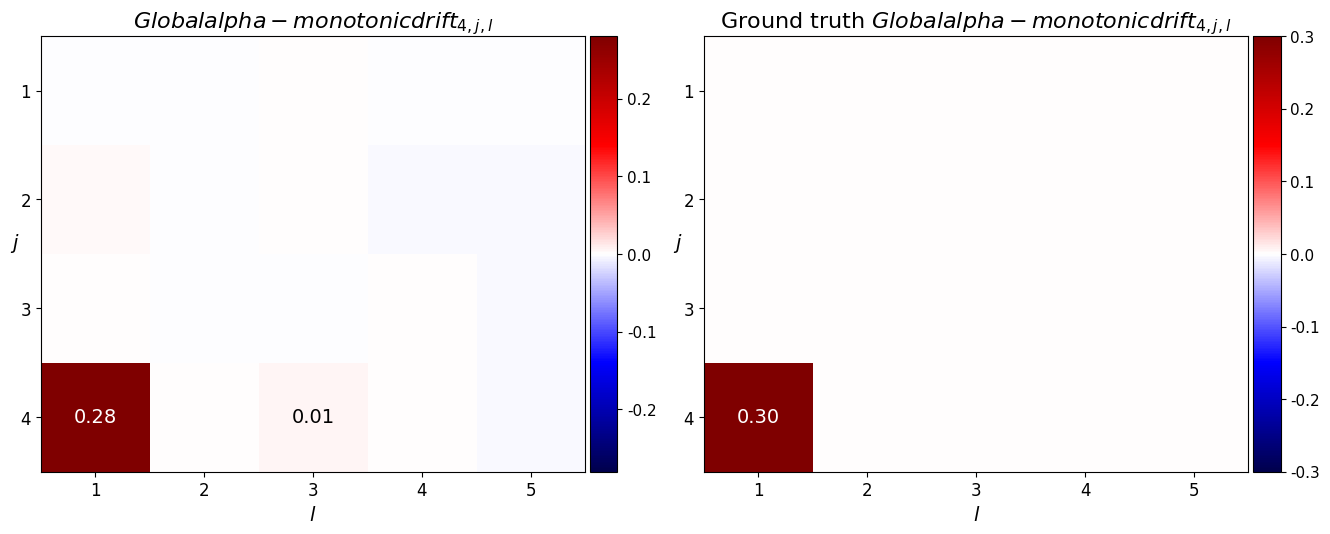

In [57]:
plot_alphas(global_alpha_drift, ground_truth_alpha_drift, title="Global alpha - monotonic drift", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats_drift["f"][1]["mean"], alpha_mask_drift, title=r"f - monotonic drift", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats_drift["c"][1]["mean"], alpha_mask_drift, title=r"C - monotonic drift", figsize=(8, 7), font_size=14, space=0.15, force_12=True)



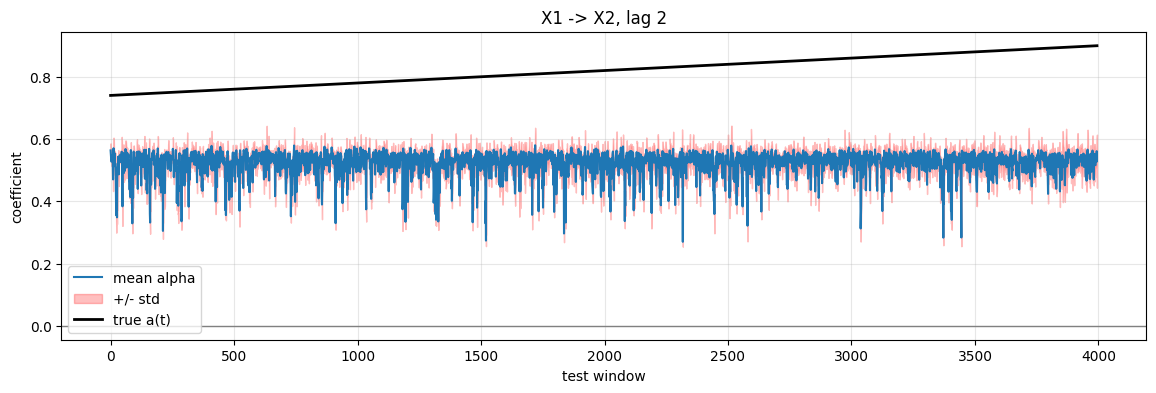

corr(alpha, a(t)): 0.052597430166640584
RMSE alpha: 0.30313065064054273
calibrated RMSE: 0.046068734828270605


In [58]:
alpha_mean_t_drift, alpha_std_t_drift = alpha_over_runs(results_drift)

plot_alpha_vs_true(
    alpha_mean_t_drift,
    alpha_std_t_drift,
    a_t_test_drift,
    target=1,
    source=0,
    lag=1,
    names=names,
)



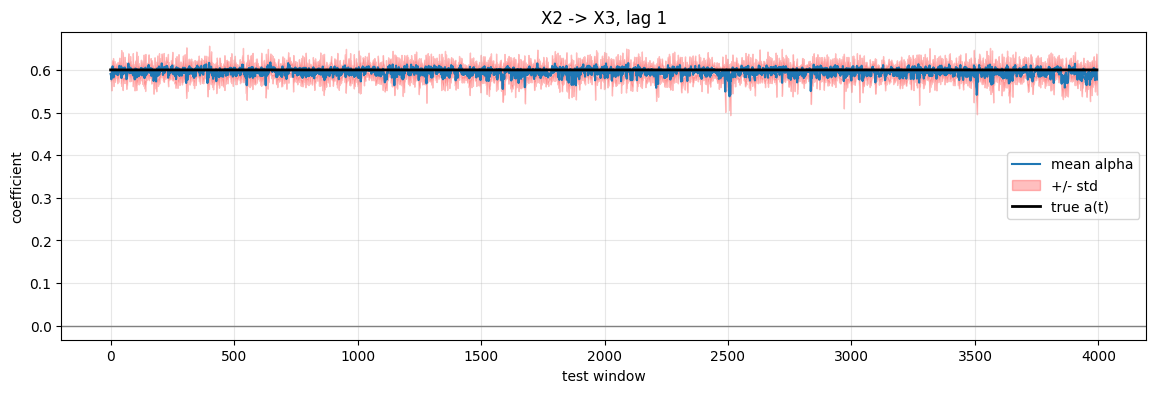

corr(alpha, a(t)): nan
RMSE alpha: 0.009985031923005453
calibrated RMSE: nan


In [59]:
plot_alpha_vs_true(alpha_mean_t_drift, alpha_std_t_drift, np.full_like(a_t_test_drift, 0.6), target=2, source=1, lag=0, names=names)


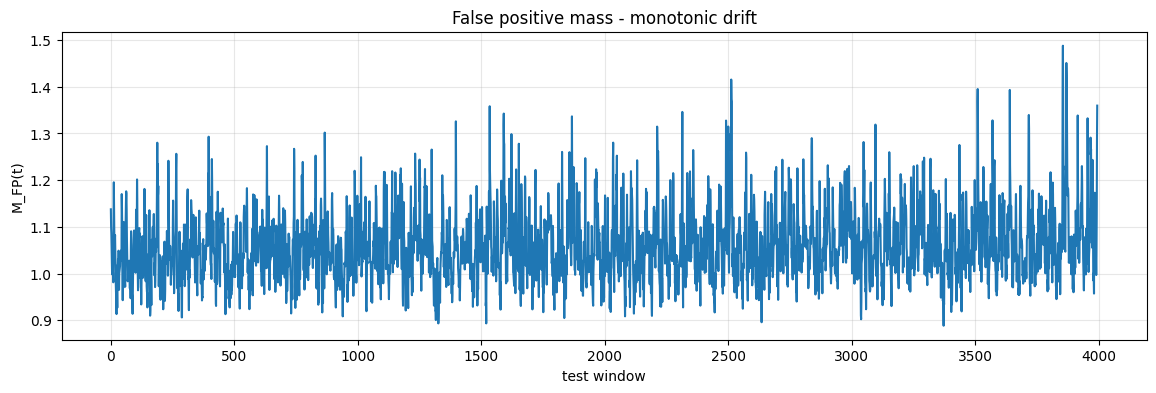

mean M_FP: 1.0586373
max M_FP: 1.4878852


In [60]:
true_mask_drift = ground_truth_alpha_drift.numpy() != 0
true_mask_drift[1, 0, 1] = True
mfp_drift = np.abs(alpha_mean_t_drift[:, ~true_mask_drift]).sum(axis=1)

plt.figure(figsize=(14, 4))
plt.plot(mfp_drift)
plt.xlabel("test window")
plt.ylabel("M_FP(t)")
plt.title("False positive mass - monotonic drift")
plt.grid(alpha=0.3)
plt.show()

print("mean M_FP:", mfp_drift.mean())
print("max M_FP:", mfp_drift.max())


In [ ]:
drift_prediction_metrics, drift_summary_metrics, drift_lag_sign_table, drift_link_table, drift_false_positive_table = task3_metrics(
    results_drift,
    stats_drift,
    ground_truth_alpha_drift,
    alpha_mean_t_drift,
    alpha_std_t_drift,
    a_t_test_drift,
    "monotonic drift",
    names,
)

display(drift_prediction_metrics)
display(drift_summary_metrics)
display(drift_lag_sign_table)
display(drift_link_table)
display(drift_false_positive_table)


In [ ]:
L = window_length_gp

train_end_global_drift = int(0.8 * ts_length)
test_start_global_drift = train_end_global_drift + L

data_drift = pd.DataFrame(time_series_drift.T, columns=names)

global_fit_drift = VAR(data_drift.iloc[:train_end_global_drift]).fit(L)

global_pred_drift = []

for t in range(test_start_global_drift, len(data_drift)):
    yhat = global_fit_drift.forecast(data_drift.iloc[t-L:t].values, steps=1)[0]
    global_pred_drift.append(yhat)

global_pred_drift = np.array(global_pred_drift)
global_true_drift = data_drift.iloc[test_start_global_drift:].values

print("Global VAR MSE - monotonic drift:", mean_squared_error(global_true_drift, global_pred_drift))
print("Global VAR MAE - monotonic drift:", mean_absolute_error(global_true_drift, global_pred_drift))

global_coef_drift = global_fit_drift.coefs[1, 1, 0]  # lag 2, X2 target, X1 source
print("Global VAR X1 -> X2 lag 2 - monotonic drift:", global_coef_drift)


In [ ]:
global_coef_drift = global_fit_drift.coefs[1, 1, 0]
print("Global VAR X1 -> X2 lag 2 - monotonic drift:", global_coef_drift)
print("Mean true a(t) - monotonic drift:", np.mean(a_t_test_drift))


In [ ]:
L = window_length_gp
#W = 20
W = 100

train_end = int(0.6 * ts_length)
val_end = train_end + int(0.2 * ts_length)
test_start = val_end + L

data_drift = pd.DataFrame(time_series_drift.T, columns=names)

sliding_pred_drift = []
sliding_coef_drift = []

for t in range(test_start, len(data_drift)):
    local_data = data_drift.iloc[t-W:t]

    local_fit = VAR(local_data).fit(L)
    yhat = local_fit.forecast(data_drift.iloc[t-L:t].values, steps=1)[0]

    sliding_pred_drift.append(yhat)
    sliding_coef_drift.append(local_fit.coefs[1, 1, 0])  # X1 -> X2, lag 2

sliding_pred_drift = np.array(sliding_pred_drift)
sliding_coef_drift = np.array(sliding_coef_drift)
true_drift = data_drift.iloc[test_start:].values

print("Sliding VAR MSE - monotonic drift:", mean_squared_error(true_drift, sliding_pred_drift))
print("Sliding VAR MAE - monotonic drift:", mean_absolute_error(true_drift, sliding_pred_drift))


In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(sliding_coef_drift, label="sliding VAR")
plt.axhline(global_coef_drift, color="red", linestyle="--", label="global VAR")
plt.plot(a_t_test_drift, color="black", linestyle="--", alpha=0.7, linewidth=2, label="true a(t)")

plt.xlabel("test window")
plt.ylabel("coefficient")
plt.title("VAR comparison: X1 -> X2, lag 2 - monotonic drift")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Gaussian_pulse


In [61]:
results_pulse = collect_multiple_runs(
    n_runs=n_runs,
    time_series=time_series_pulse,
    window_size=window_length_gp,
    temperature=temperature,
    order=order,
    config=train_config,
    verbose=True,
)

stats_pulse = calculate_multiple_run_statistics(results_pulse)
global_alpha_pulse = stats_pulse["alpha"][1]["mean"]



Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 2.600736e-01
Starting Run 2/5
Run 2 completed. Test Loss: 2.592427e-01
Starting Run 3/5
Run 3 completed. Test Loss: 2.590594e-01
Starting Run 4/5
Run 4 completed. Test Loss: 2.597231e-01
Starting Run 5/5
Run 5 completed. Test Loss: 2.596674e-01
Time taken for 5 run(s): 37.65 seconds


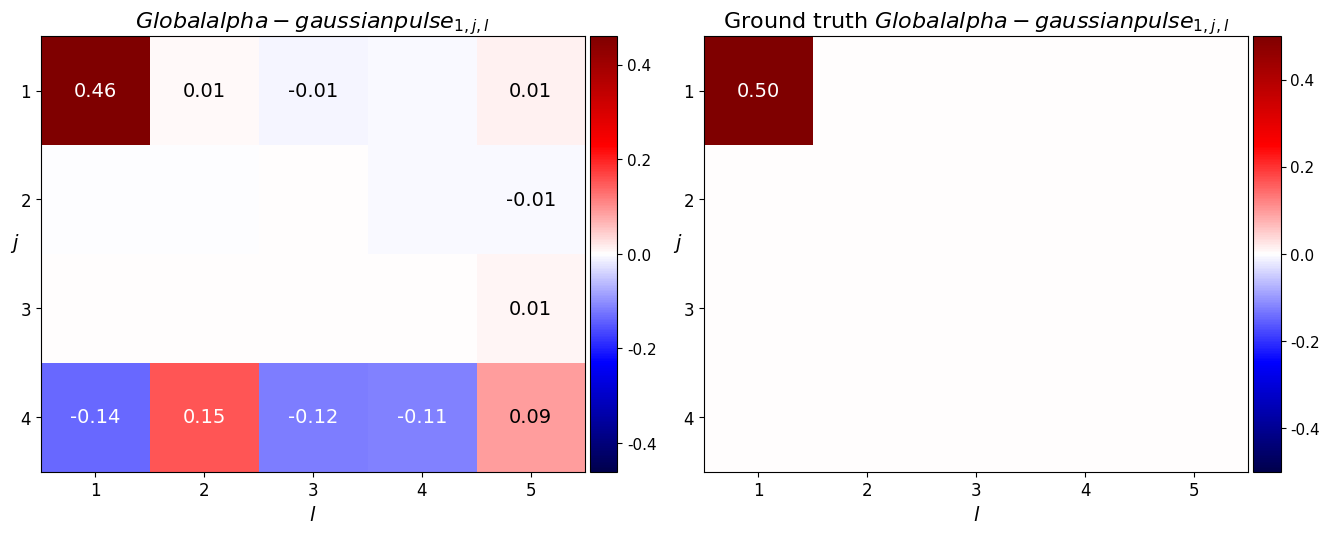

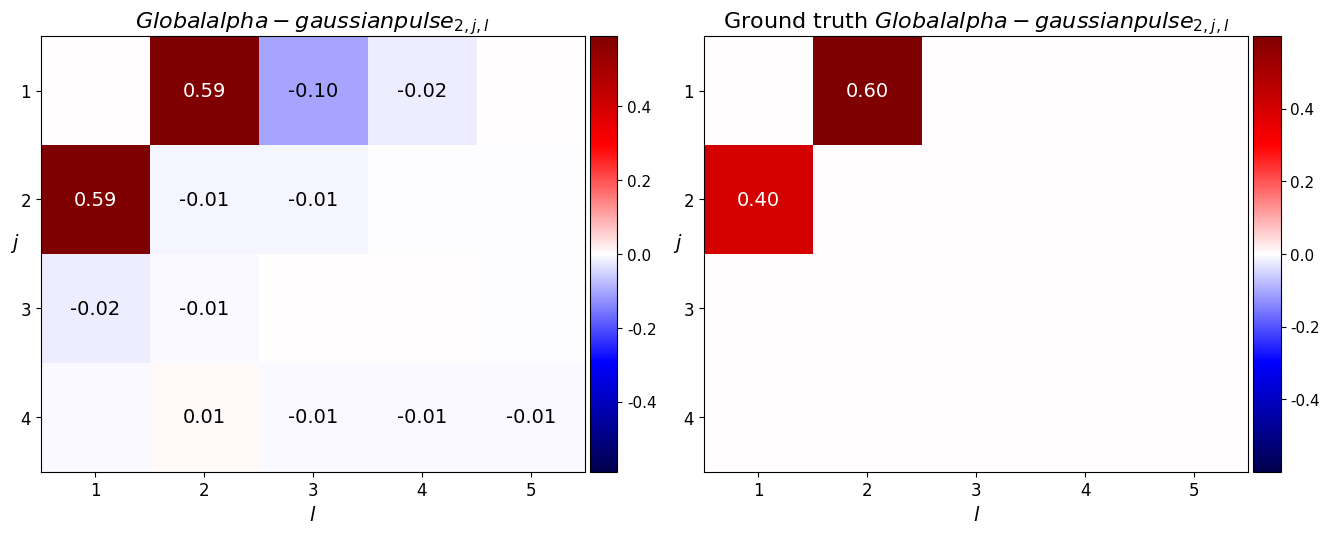

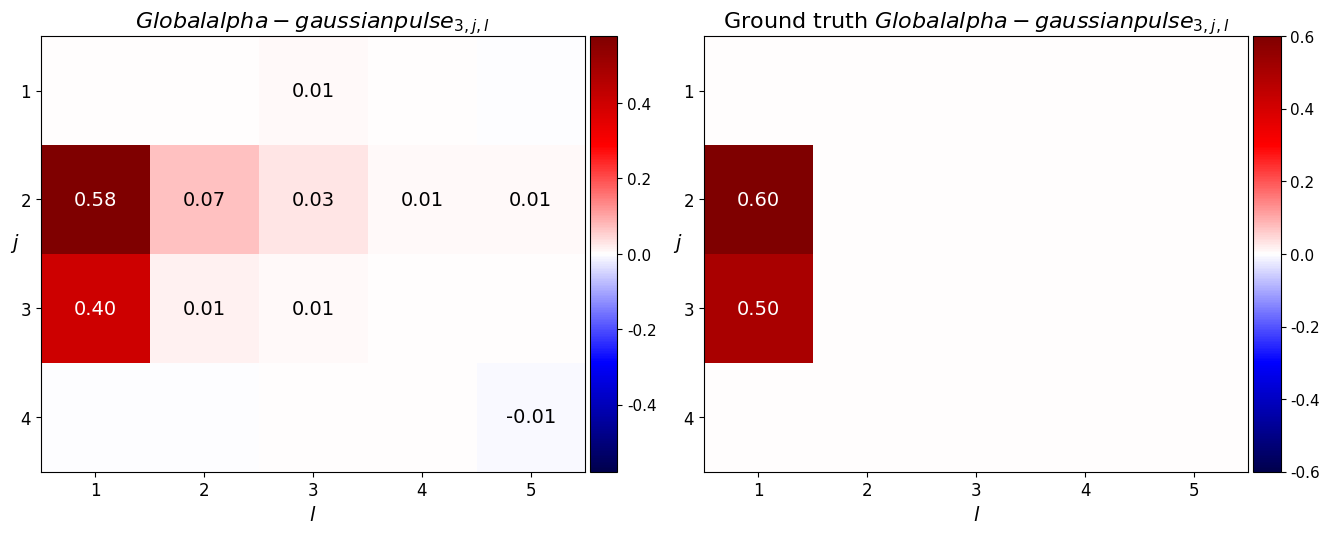

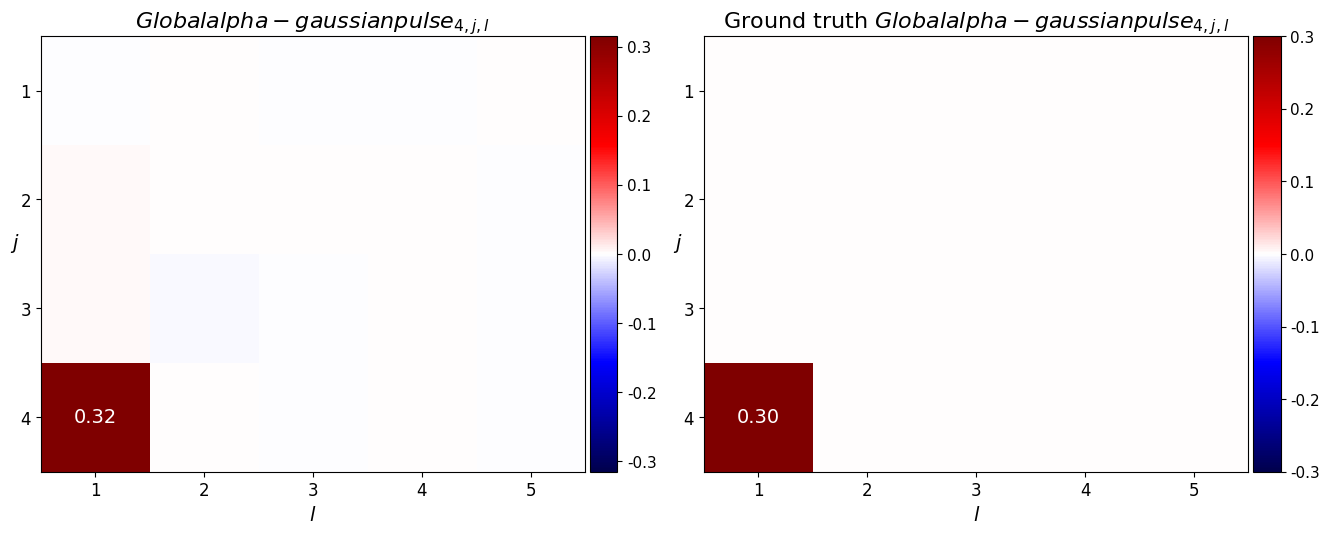

In [62]:
plot_alphas(global_alpha_pulse, ground_truth_alpha_pulse, title="Global alpha - gaussian pulse", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats_pulse["f"][1]["mean"], alpha_mask_pulse, title=r"f - gaussian pulse", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats_pulse["c"][1]["mean"], alpha_mask_pulse, title=r"C - gaussian pulse", figsize=(8, 7), font_size=14, space=0.15, force_12=True)



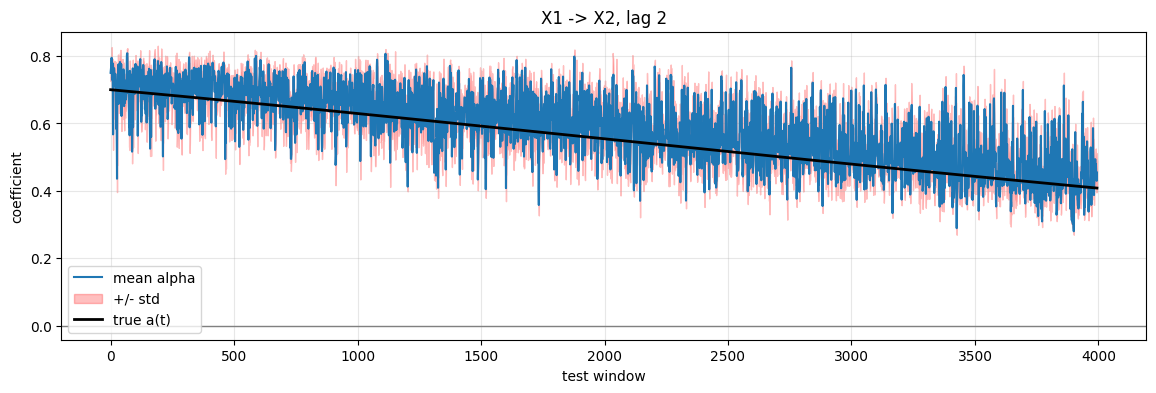

corr(alpha, a(t)): 0.7712985680211093
RMSE alpha: 0.07369125944967425
calibrated RMSE: 0.05443449006917922


In [63]:
alpha_mean_t_pulse, alpha_std_t_pulse = alpha_over_runs(results_pulse)

plot_alpha_vs_true(
    alpha_mean_t_pulse,
    alpha_std_t_pulse,
    a_t_test_pulse,
    target=1,
    source=0,
    lag=1,
    names=names,
)



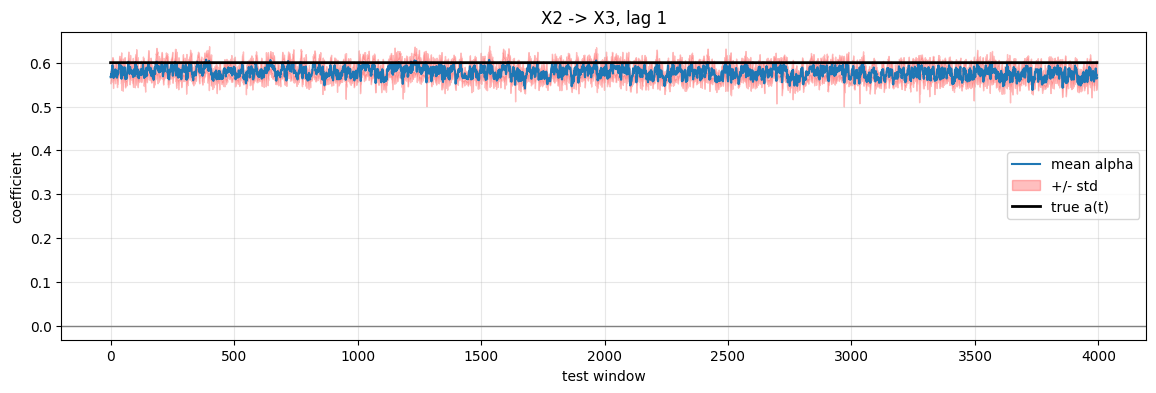

corr(alpha, a(t)): nan
RMSE alpha: 0.02512894882875786
calibrated RMSE: nan


In [64]:
plot_alpha_vs_true(alpha_mean_t_pulse, alpha_std_t_pulse, np.full_like(a_t_test_pulse, 0.6), target=2, source=1, lag=0, names=names)


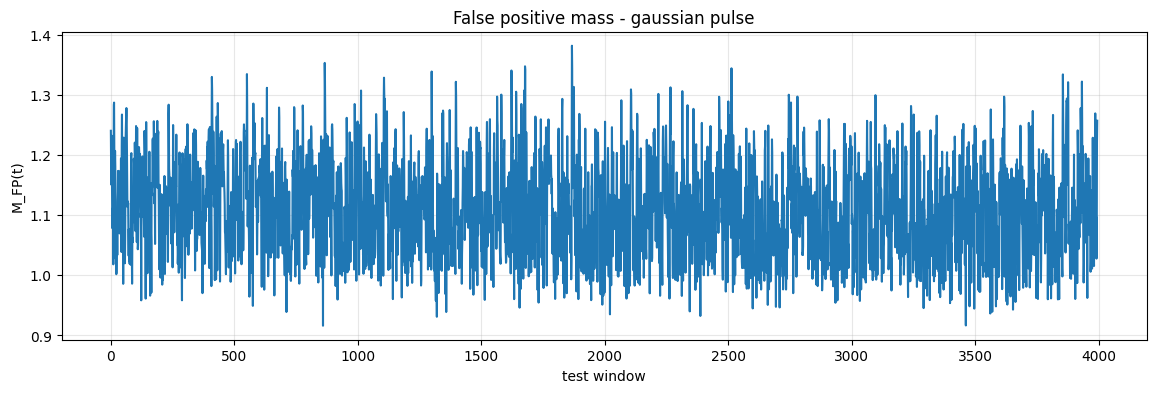

mean M_FP: 1.1091064
max M_FP: 1.381973


In [65]:
true_mask_pulse = ground_truth_alpha_pulse.numpy() != 0
true_mask_pulse[1, 0, 1] = True
mfp_pulse = np.abs(alpha_mean_t_pulse[:, ~true_mask_pulse]).sum(axis=1)

plt.figure(figsize=(14, 4))
plt.plot(mfp_pulse)
plt.xlabel("test window")
plt.ylabel("M_FP(t)")
plt.title("False positive mass - gaussian pulse")
plt.grid(alpha=0.3)
plt.show()

print("mean M_FP:", mfp_pulse.mean())
print("max M_FP:", mfp_pulse.max())


In [ ]:
pulse_prediction_metrics, pulse_summary_metrics, pulse_lag_sign_table, pulse_link_table, pulse_false_positive_table = task3_metrics(
    results_pulse,
    stats_pulse,
    ground_truth_alpha_pulse,
    alpha_mean_t_pulse,
    alpha_std_t_pulse,
    a_t_test_pulse,
    "gaussian pulse",
    names,
)

display(pulse_prediction_metrics)
display(pulse_summary_metrics)
display(pulse_lag_sign_table)
display(pulse_link_table)
display(pulse_false_positive_table)


In [ ]:
L = window_length_gp

train_end_global_pulse = int(0.8 * ts_length)
test_start_global_pulse = train_end_global_pulse + L

data_pulse = pd.DataFrame(time_series_pulse.T, columns=names)

global_fit_pulse = VAR(data_pulse.iloc[:train_end_global_pulse]).fit(L)

global_pred_pulse = []

for t in range(test_start_global_pulse, len(data_pulse)):
    yhat = global_fit_pulse.forecast(data_pulse.iloc[t-L:t].values, steps=1)[0]
    global_pred_pulse.append(yhat)

global_pred_pulse = np.array(global_pred_pulse)
global_true_pulse = data_pulse.iloc[test_start_global_pulse:].values

print("Global VAR MSE - gaussian pulse:", mean_squared_error(global_true_pulse, global_pred_pulse))
print("Global VAR MAE - gaussian pulse:", mean_absolute_error(global_true_pulse, global_pred_pulse))

global_coef_pulse = global_fit_pulse.coefs[1, 1, 0]  # lag 2, X2 target, X1 source
print("Global VAR X1 -> X2 lag 2 - gaussian pulse:", global_coef_pulse)


In [ ]:
global_coef_pulse = global_fit_pulse.coefs[1, 1, 0]
print("Global VAR X1 -> X2 lag 2 - gaussian pulse:", global_coef_pulse)
print("Mean true a(t) - gaussian pulse:", np.mean(a_t_test_pulse))


In [ ]:
L = window_length_gp
#W = 20
W = 100

train_end = int(0.6 * ts_length)
val_end = train_end + int(0.2 * ts_length)
test_start = val_end + L

data_pulse = pd.DataFrame(time_series_pulse.T, columns=names)

sliding_pred_pulse = []
sliding_coef_pulse = []

for t in range(test_start, len(data_pulse)):
    local_data = data_pulse.iloc[t-W:t]

    local_fit = VAR(local_data).fit(L)
    yhat = local_fit.forecast(data_pulse.iloc[t-L:t].values, steps=1)[0]

    sliding_pred_pulse.append(yhat)
    sliding_coef_pulse.append(local_fit.coefs[1, 1, 0])  # X1 -> X2, lag 2

sliding_pred_pulse = np.array(sliding_pred_pulse)
sliding_coef_pulse = np.array(sliding_coef_pulse)
true_pulse = data_pulse.iloc[test_start:].values

print("Sliding VAR MSE - gaussian pulse:", mean_squared_error(true_pulse, sliding_pred_pulse))
print("Sliding VAR MAE - gaussian pulse:", mean_absolute_error(true_pulse, sliding_pred_pulse))


In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(sliding_coef_pulse, label="sliding VAR")
plt.axhline(global_coef_pulse, color="red", linestyle="--", label="global VAR")
plt.plot(a_t_test_pulse, color="black", linestyle="--", alpha=0.7, linewidth=2, label="true a(t)")

plt.xlabel("test window")
plt.ylabel("coefficient")
plt.title("VAR comparison: X1 -> X2, lag 2 - gaussian pulse")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Zero_crossing_sine


In [66]:
results_zero = collect_multiple_runs(
    n_runs=n_runs,
    time_series=time_series_zero,
    window_size=window_length_gp,
    temperature=temperature,
    order=order,
    config=train_config,
    verbose=True,
)

stats_zero = calculate_multiple_run_statistics(results_zero)
global_alpha_zero = stats_zero["alpha"][1]["mean"]



Training Configuration:
  verbose: False
  device: cuda:0
  learning_rate: 0.001
  scheduler_patience: 5
  early_stopping_modifier: 2
  criterion: MSELoss()
Starting Run 1/5
Run 1 completed. Test Loss: 2.609163e-01
Starting Run 2/5
Run 2 completed. Test Loss: 2.625974e-01
Starting Run 3/5
Run 3 completed. Test Loss: 2.624128e-01
Starting Run 4/5
Run 4 completed. Test Loss: 2.618643e-01
Starting Run 5/5
Run 5 completed. Test Loss: 2.617106e-01
Time taken for 5 run(s): 34.60 seconds


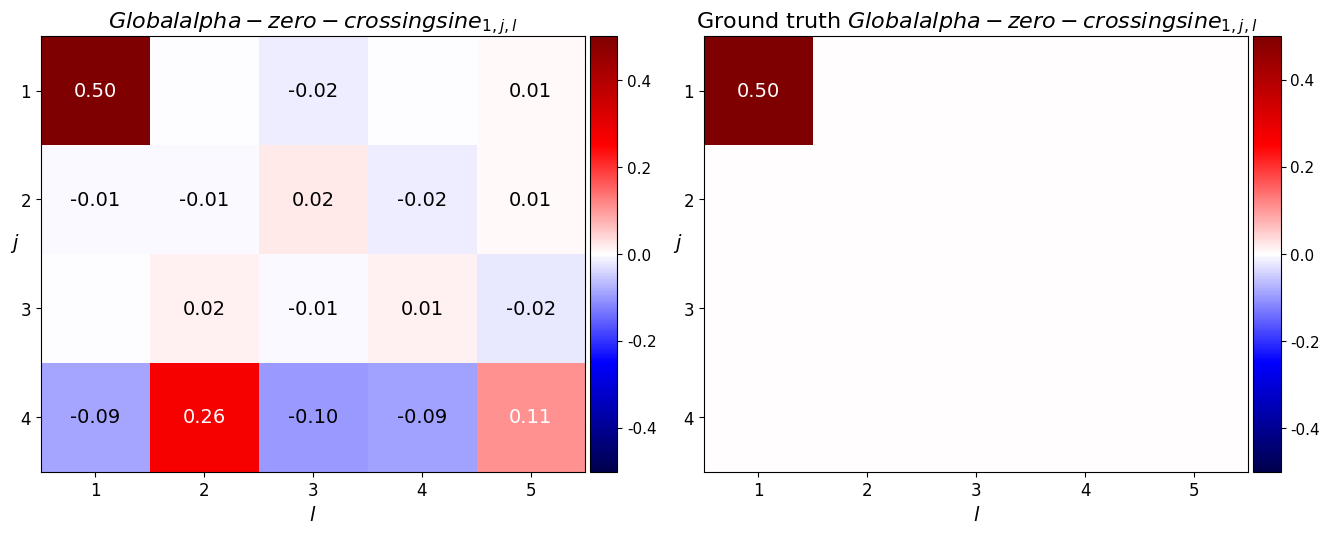

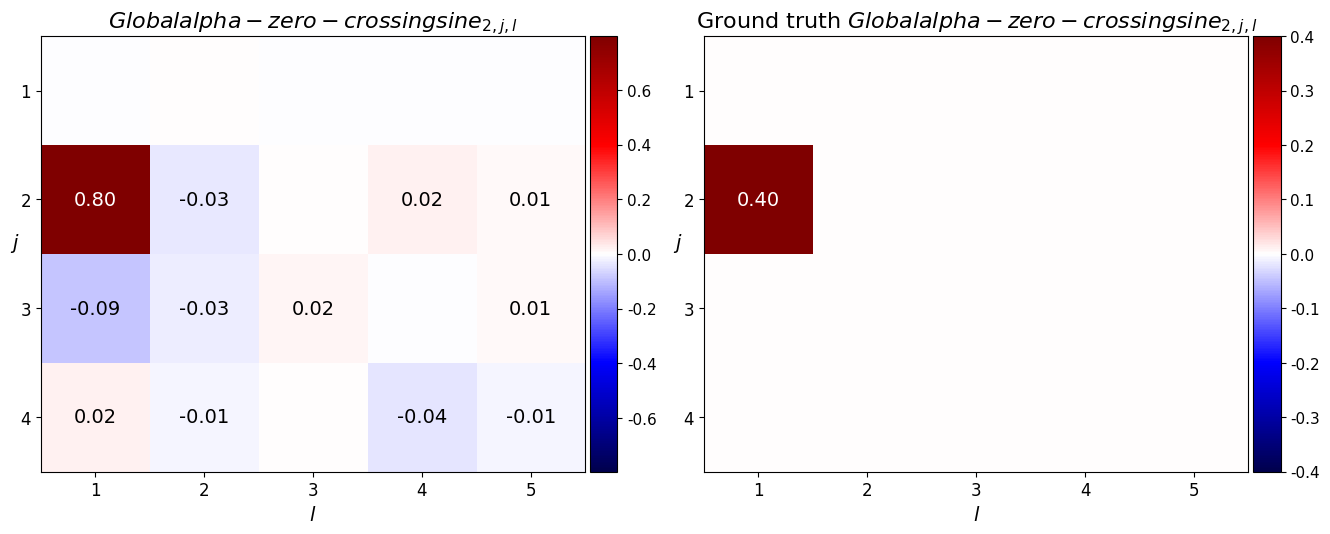

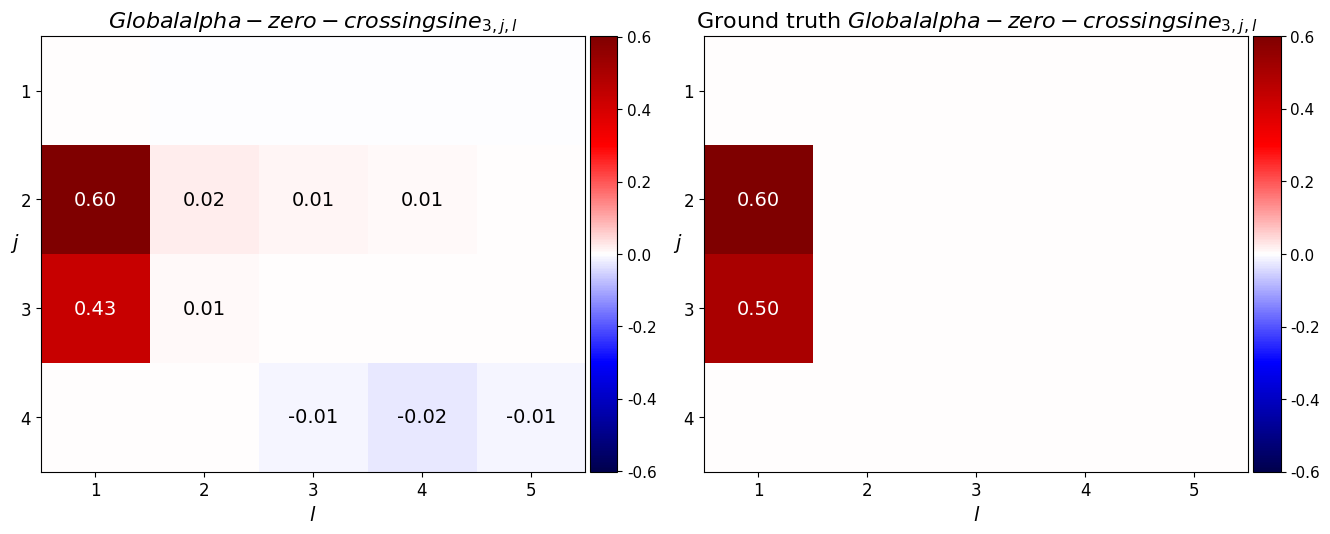

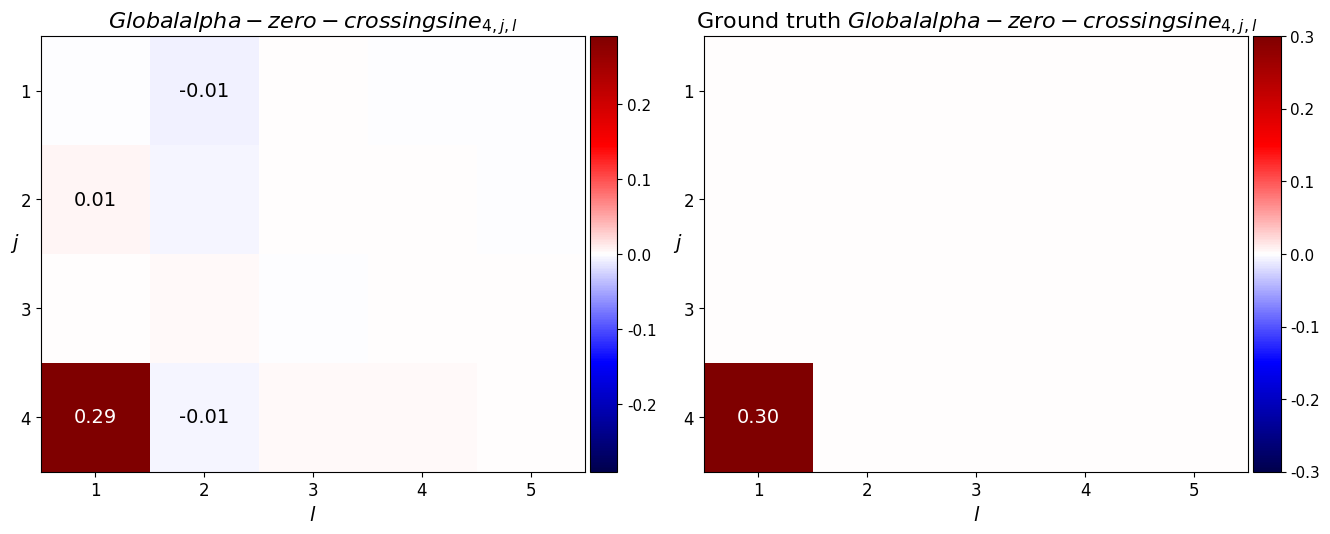

In [67]:
plot_alphas(global_alpha_zero, ground_truth_alpha_zero, title="Global alpha - zero-crossing sine", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats_zero["f"][1]["mean"], alpha_mask_zero, title=r"f - zero-crossing sine", figsize=(8, 7), font_size=14, space=0.15, force_12=True)

#plot_alphas(stats_zero["c"][1]["mean"], alpha_mask_zero, title=r"C - zero-crossing sine", figsize=(8, 7), font_size=14, space=0.15, force_12=True)



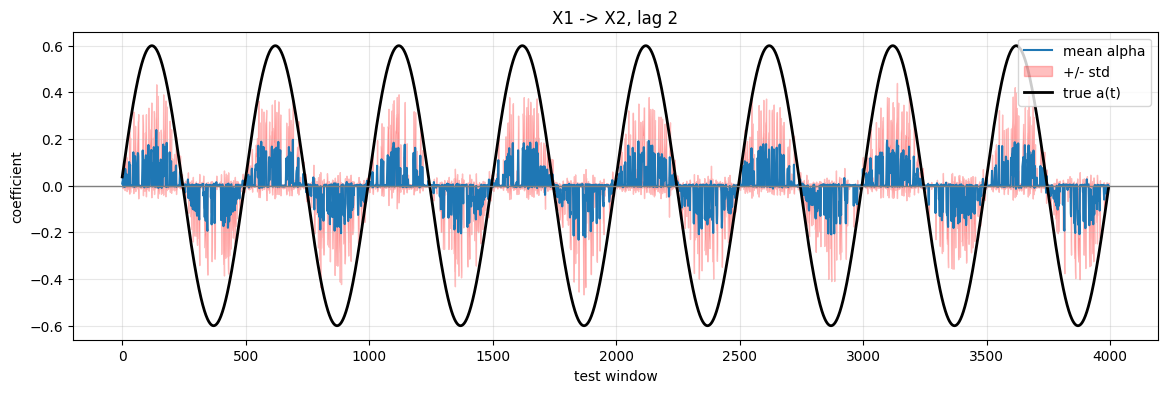

corr(alpha, a(t)): 0.5974637245881216
RMSE alpha: 0.39028055117469623
calibrated RMSE: 0.34042806503051637


In [68]:
alpha_mean_t_zero, alpha_std_t_zero = alpha_over_runs(results_zero)

plot_alpha_vs_true(
    alpha_mean_t_zero,
    alpha_std_t_zero,
    a_t_test_zero,
    target=1,
    source=0,
    lag=1,
    names=names,
)



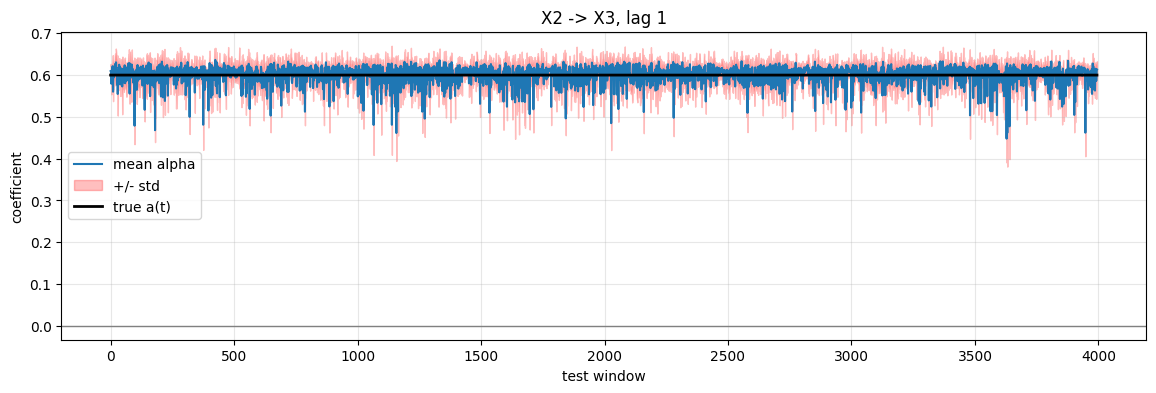

corr(alpha, a(t)): nan
RMSE alpha: 0.019962362496413002
calibrated RMSE: nan


In [69]:
plot_alpha_vs_true(alpha_mean_t_zero, alpha_std_t_zero, np.full_like(a_t_test_zero, 0.6), target=2, source=1, lag=0, names=names)


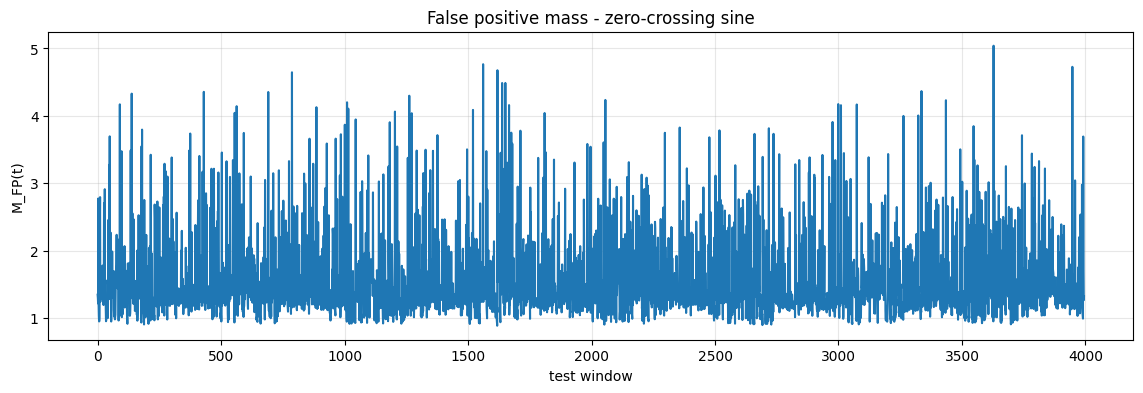

mean M_FP: 1.5186665
max M_FP: 5.0411487


In [70]:
true_mask_zero = ground_truth_alpha_zero.numpy() != 0
true_mask_zero[1, 0, 1] = True
mfp_zero = np.abs(alpha_mean_t_zero[:, ~true_mask_zero]).sum(axis=1)

plt.figure(figsize=(14, 4))
plt.plot(mfp_zero)
plt.xlabel("test window")
plt.ylabel("M_FP(t)")
plt.title("False positive mass - zero-crossing sine")
plt.grid(alpha=0.3)
plt.show()

print("mean M_FP:", mfp_zero.mean())
print("max M_FP:", mfp_zero.max())


In [ ]:
zero_prediction_metrics, zero_summary_metrics, zero_lag_sign_table, zero_link_table, zero_false_positive_table = task3_metrics(
    results_zero,
    stats_zero,
    ground_truth_alpha_zero,
    alpha_mean_t_zero,
    alpha_std_t_zero,
    a_t_test_zero,
    "zero-crossing sine",
    names,
)

display(zero_prediction_metrics)
display(zero_summary_metrics)
display(zero_lag_sign_table)
display(zero_link_table)
display(zero_false_positive_table)


In [ ]:
L = window_length_gp

train_end_global_zero = int(0.8 * ts_length)
test_start_global_zero = train_end_global_zero + L

data_zero = pd.DataFrame(time_series_zero.T, columns=names)

global_fit_zero = VAR(data_zero.iloc[:train_end_global_zero]).fit(L)

global_pred_zero = []

for t in range(test_start_global_zero, len(data_zero)):
    yhat = global_fit_zero.forecast(data_zero.iloc[t-L:t].values, steps=1)[0]
    global_pred_zero.append(yhat)

global_pred_zero = np.array(global_pred_zero)
global_true_zero = data_zero.iloc[test_start_global_zero:].values

print("Global VAR MSE - zero-crossing sine:", mean_squared_error(global_true_zero, global_pred_zero))
print("Global VAR MAE - zero-crossing sine:", mean_absolute_error(global_true_zero, global_pred_zero))

global_coef_zero = global_fit_zero.coefs[1, 1, 0]  # lag 2, X2 target, X1 source
print("Global VAR X1 -> X2 lag 2 - zero-crossing sine:", global_coef_zero)


In [ ]:
global_coef_zero = global_fit_zero.coefs[1, 1, 0]
print("Global VAR X1 -> X2 lag 2 - zero-crossing sine:", global_coef_zero)
print("Mean true a(t) - zero-crossing sine:", np.mean(a_t_test_zero))


In [ ]:
L = window_length_gp
#W = 20
W = 100

train_end = int(0.6 * ts_length)
val_end = train_end + int(0.2 * ts_length)
test_start = val_end + L

data_zero = pd.DataFrame(time_series_zero.T, columns=names)

sliding_pred_zero = []
sliding_coef_zero = []

for t in range(test_start, len(data_zero)):
    local_data = data_zero.iloc[t-W:t]

    local_fit = VAR(local_data).fit(L)
    yhat = local_fit.forecast(data_zero.iloc[t-L:t].values, steps=1)[0]

    sliding_pred_zero.append(yhat)
    sliding_coef_zero.append(local_fit.coefs[1, 1, 0])  # X1 -> X2, lag 2

sliding_pred_zero = np.array(sliding_pred_zero)
sliding_coef_zero = np.array(sliding_coef_zero)
true_zero = data_zero.iloc[test_start:].values

print("Sliding VAR MSE - zero-crossing sine:", mean_squared_error(true_zero, sliding_pred_zero))
print("Sliding VAR MAE - zero-crossing sine:", mean_absolute_error(true_zero, sliding_pred_zero))


In [ ]:
plt.figure(figsize=(14, 4))

plt.plot(sliding_coef_zero, label="sliding VAR")
plt.axhline(global_coef_zero, color="red", linestyle="--", label="global VAR")
plt.plot(a_t_test_zero, color="black", linestyle="--", alpha=0.7, linewidth=2, label="true a(t)")

plt.xlabel("test window")
plt.ylabel("coefficient")
plt.title("VAR comparison: X1 -> X2, lag 2 - zero-crossing sine")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
task3_prediction_table = pd.concat([
    sin_prediction_metrics,
    drift_prediction_metrics,
    pulse_prediction_metrics,
    zero_prediction_metrics,
], ignore_index=True)

task3_summary_table = pd.concat([
    sin_summary_metrics,
    drift_summary_metrics,
    pulse_summary_metrics,
    zero_summary_metrics,
], ignore_index=True)

display(task3_prediction_table)
display(task3_summary_table)
